In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
prices_0 = pd.read_csv("data/prices_round_3_day_0.csv", delimiter=';')
prices_1 = pd.read_csv("data/prices_round_3_day_1.csv", delimiter=';')
prices_2 = pd.read_csv("data/prices_round_3_day_2.csv", delimiter=';')

trades_0 = pd.read_csv("data/trades_round_3_day_0.csv", delimiter=';')
trades_1 = pd.read_csv("data/trades_round_3_day_1.csv", delimiter=';')
trades_2 = pd.read_csv("data/trades_round_3_day_2.csv", delimiter=';')

In [9]:
OFFSET = 1_000_000

prices_0['global_timestamp'] = prices_0['timestamp'] + 0 * OFFSET
prices_1['global_timestamp'] = prices_1['timestamp'] + 1 * OFFSET
prices_2['global_timestamp'] = prices_2['timestamp'] + 2 * OFFSET

prices_all = pd.concat([prices_0, prices_1, prices_2], ignore_index=True).sort_values('global_timestamp').reset_index(drop=True)
print(prices_all.shape)
prices_all.head()

(360000, 18)


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,global_timestamp
0,0,0,VEV_5400,22,25,NaN,NaN,NaN,NaN,24,25,NaN,NaN,NaN,NaN,23.0,0.0,0
1,0,0,VEV_6000,0,25,NaN,NaN,NaN,NaN,1,25,NaN,NaN,NaN,NaN,0.5,0.0,0
2,0,0,VEV_5100,169,19,NaN,NaN,NaN,NaN,174,19,NaN,NaN,NaN,NaN,171.5,0.0,0
3,0,0,VEV_4000,1240,7,1237.0,24.0,NaN,NaN,1260,7,1263.0,24.0,NaN,NaN,1250.0,0.0,0
4,0,0,HYDROGEL_PACK,9992,15,9990.0,30.0,NaN,NaN,10008,15,10010.0,30.0,NaN,NaN,10000.0,0.0,0


In [10]:
products = prices_all['product'].unique()
print(f"{len(products)} products:", sorted(products))

product_dfs = {product: prices_all[prices_all['product'] == product].copy() for product in products}

12 products: ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']


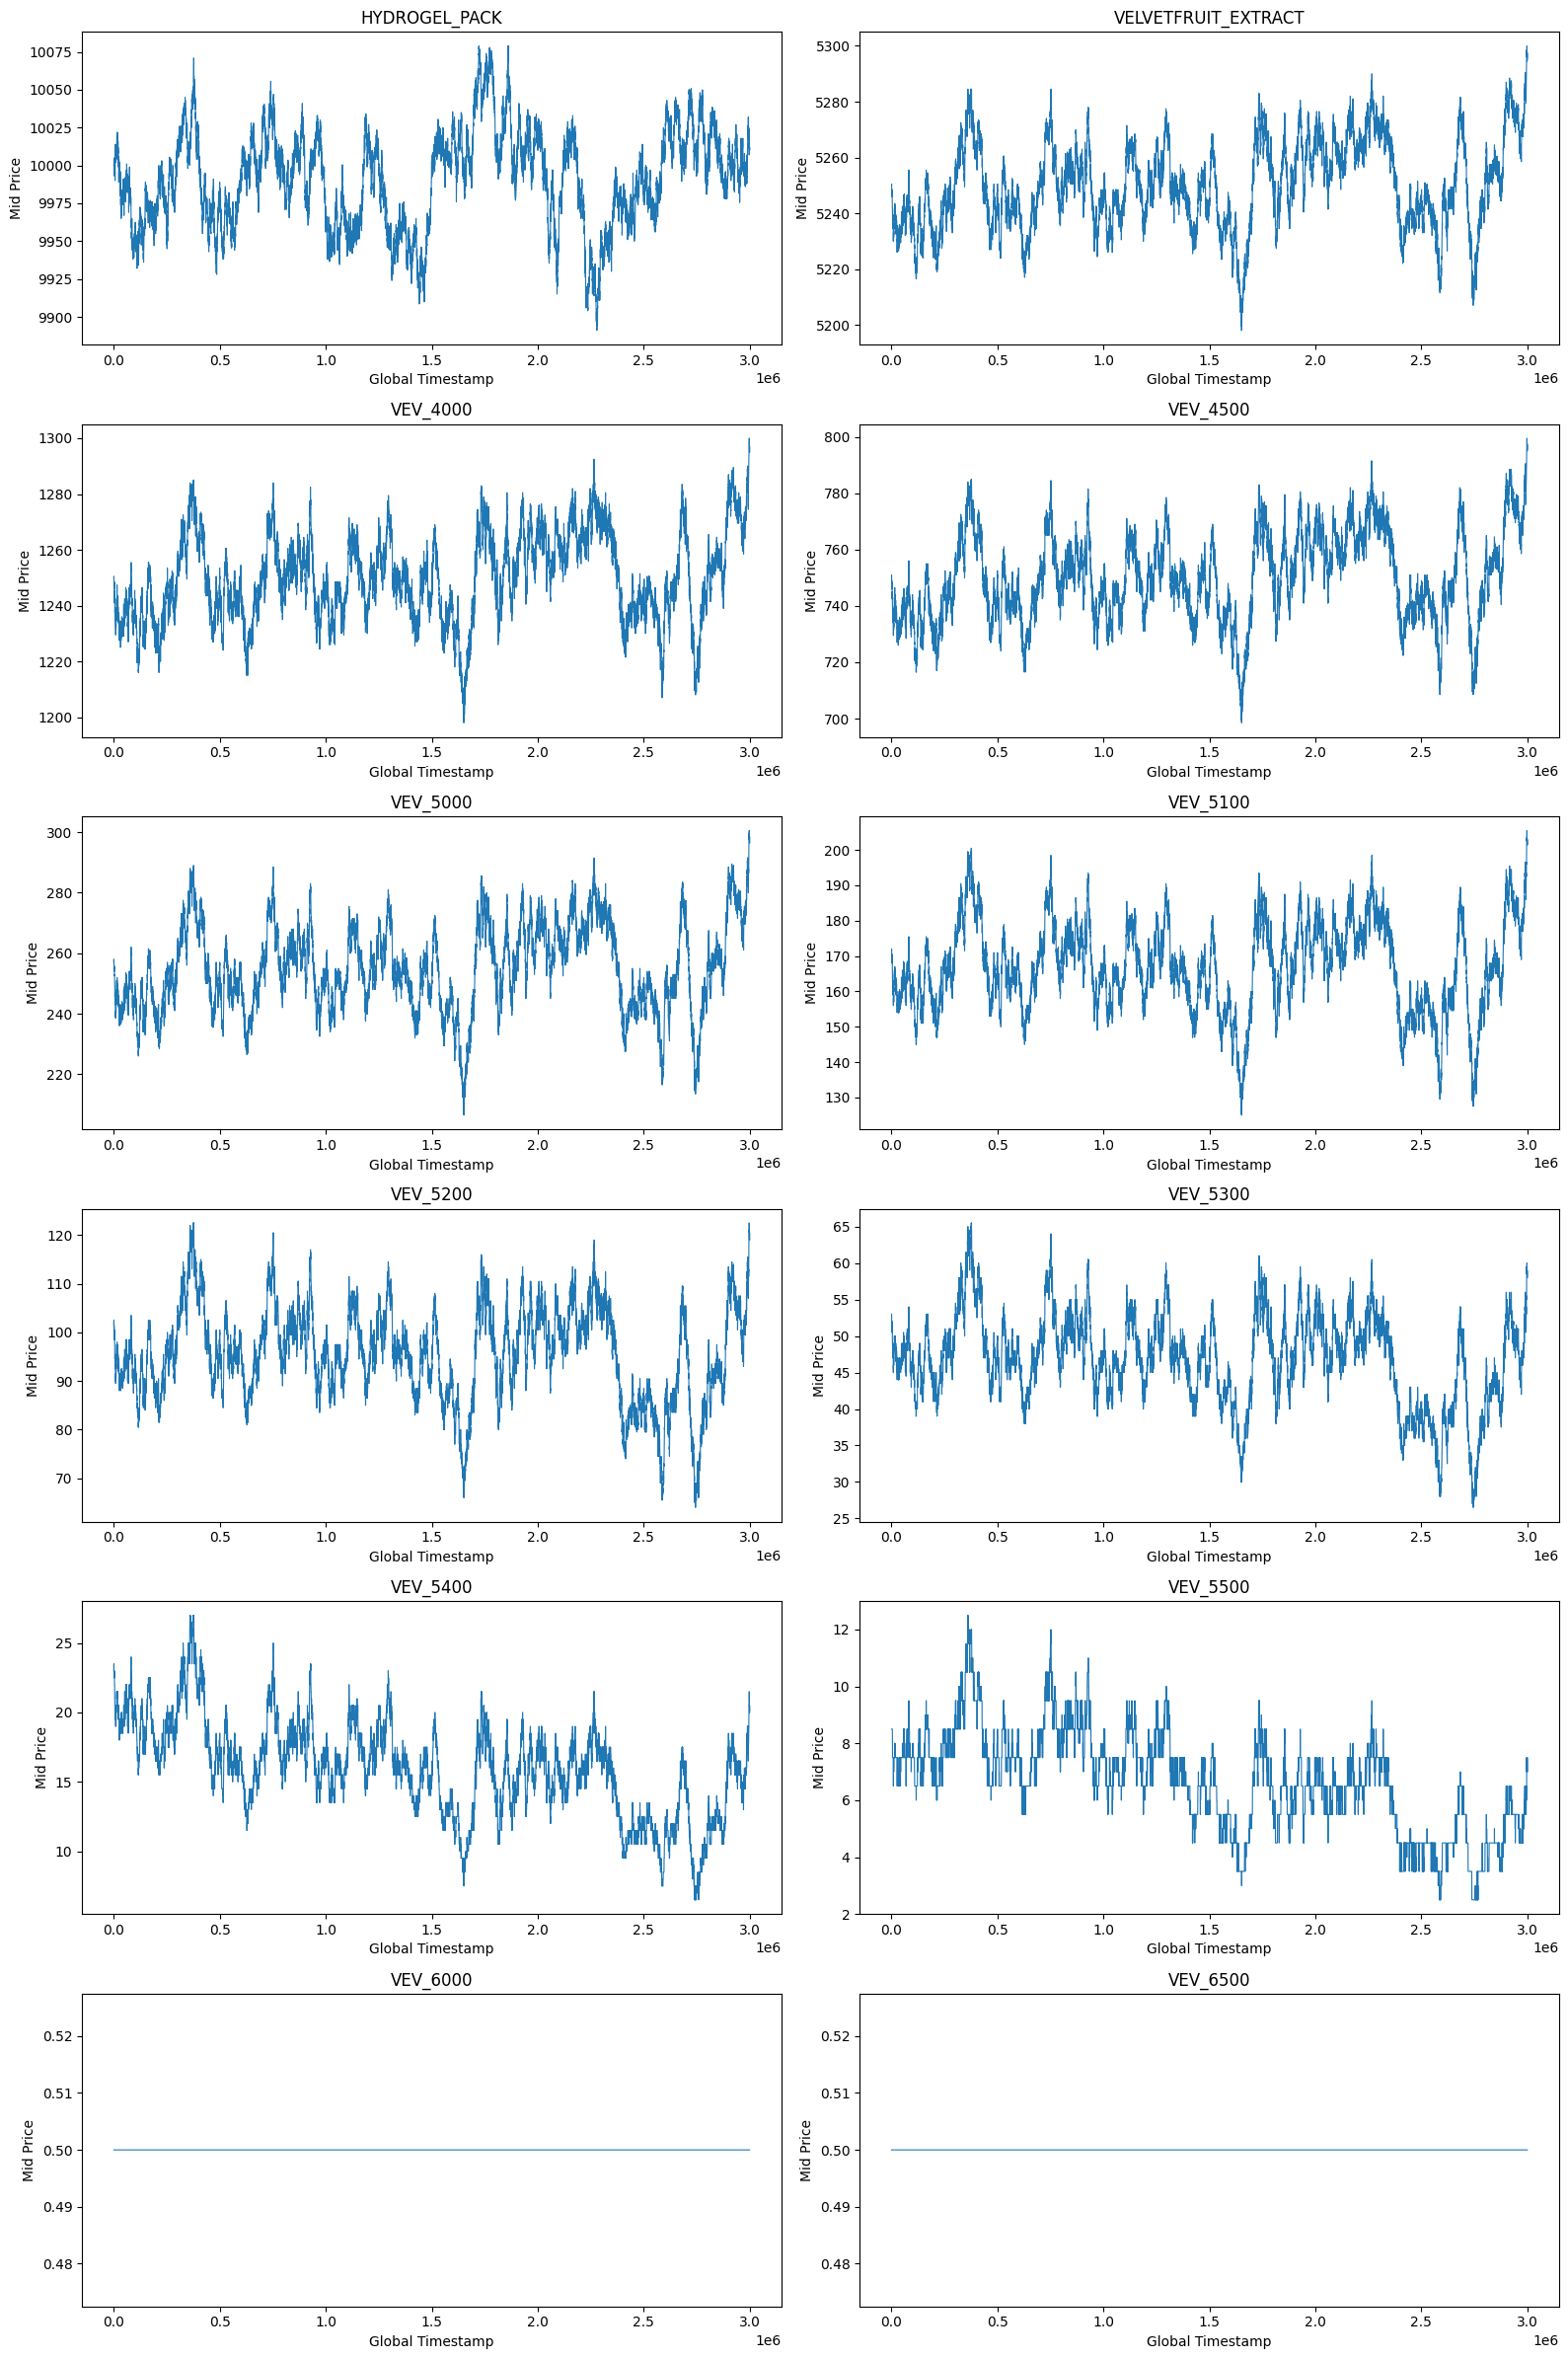

In [11]:
sorted_products = sorted(products)
n = len(sorted_products)
ncols = 2
nrows = (n + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, product in enumerate(sorted_products):
    df = product_dfs[product]
    axes[i].plot(df['global_timestamp'], df['mid_price'], linewidth=0.8)
    axes[i].set_title(product)
    axes[i].set_xlabel('Global Timestamp')
    axes[i].set_ylabel('Mid Price')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Hydrogel Pack analysis

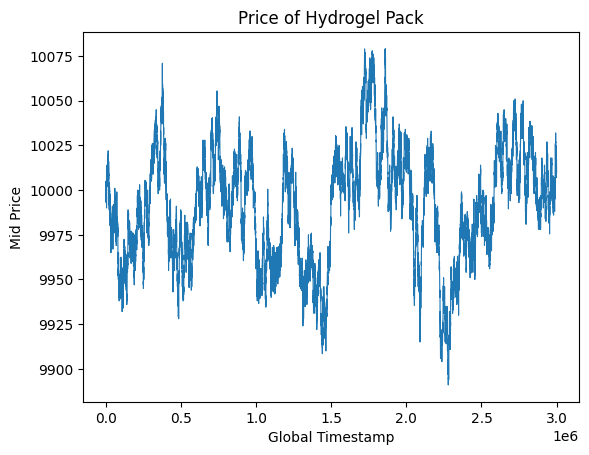

In [61]:
df = product_dfs['HYDROGEL_PACK']
plt.plot(df['global_timestamp'], df['mid_price'], linewidth=0.8)
plt.xlabel('Global Timestamp')
plt.ylabel('Mid Price')
plt.title('Price of Hydrogel Pack')
plt.show()

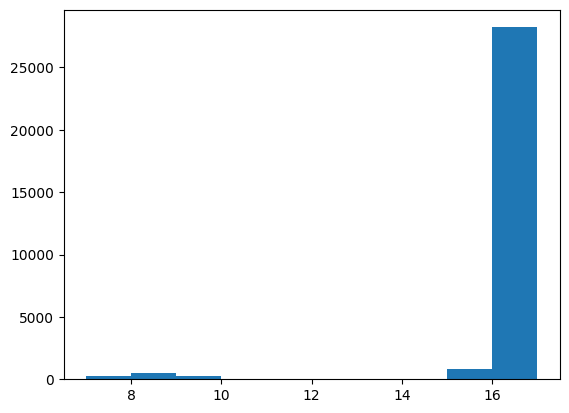

In [62]:
df['spread'] = df['ask_price_1'] - df['bid_price_1']
plt.hist(df['spread'])
plt.show()

In [63]:
df.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,...,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,global_timestamp,spread,imbalance,microprice
4,0,0,HYDROGEL_PACK,9992,15,9990.0,30.0,NaN,NaN,10008,...,10010.0,30.0,NaN,NaN,10000.0,0.0,0,16,0.0,10000.0
12,0,100,HYDROGEL_PACK,9992,13,9990.0,30.0,NaN,NaN,10008,...,10011.0,30.0,NaN,NaN,10000.0,0.0,100,16,0.0,10000.0
34,0,200,HYDROGEL_PACK,9995,13,9992.0,21.0,NaN,NaN,10011,...,10013.0,21.0,NaN,NaN,10003.0,0.0,200,16,0.0,10003.0
45,0,300,HYDROGEL_PACK,9994,11,9992.0,23.0,NaN,NaN,10010,...,10013.0,23.0,NaN,NaN,10002.0,0.0,300,16,0.0,10002.0
53,0,400,HYDROGEL_PACK,9995,13,9993.0,23.0,NaN,NaN,10011,...,10014.0,23.0,NaN,NaN,10003.0,0.0,400,16,0.0,10003.0


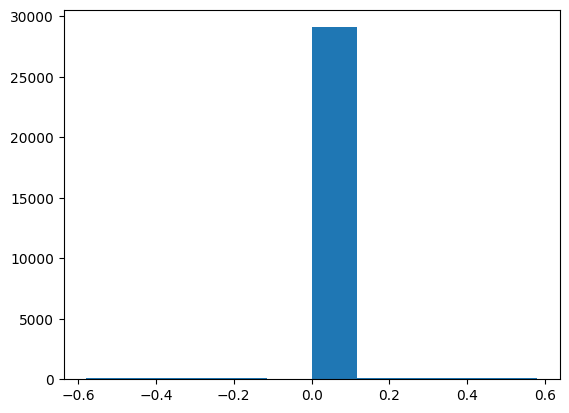

In [64]:
df['imbalance'] = (df['bid_volume_1'] - df['ask_volume_1'])/(df['bid_volume_1'] + df['ask_volume_1'])
plt.hist(df['imbalance'])
plt.show()

In [65]:
df['microprice'] = (df['bid_price_1']*df['bid_volume_1'] + df['ask_price_1']*df['ask_volume_1'])/(df['bid_volume_1'] + df['ask_volume_1'])
df['microprice']

4         10000.0
12        10000.0
34        10003.0
45        10002.0
53        10003.0
           ...   
359945    10010.0
359952    10012.0
359974    10012.0
359978    10011.0
359991    10010.0
Name: microprice, Length: 30000, dtype: float64

## Mean Reversion Strategy — Volatility Spike Detection

Enter opposite to any move exceeding 3σ from a 10-timestamp rolling window. Exit when |z| drops below 1.

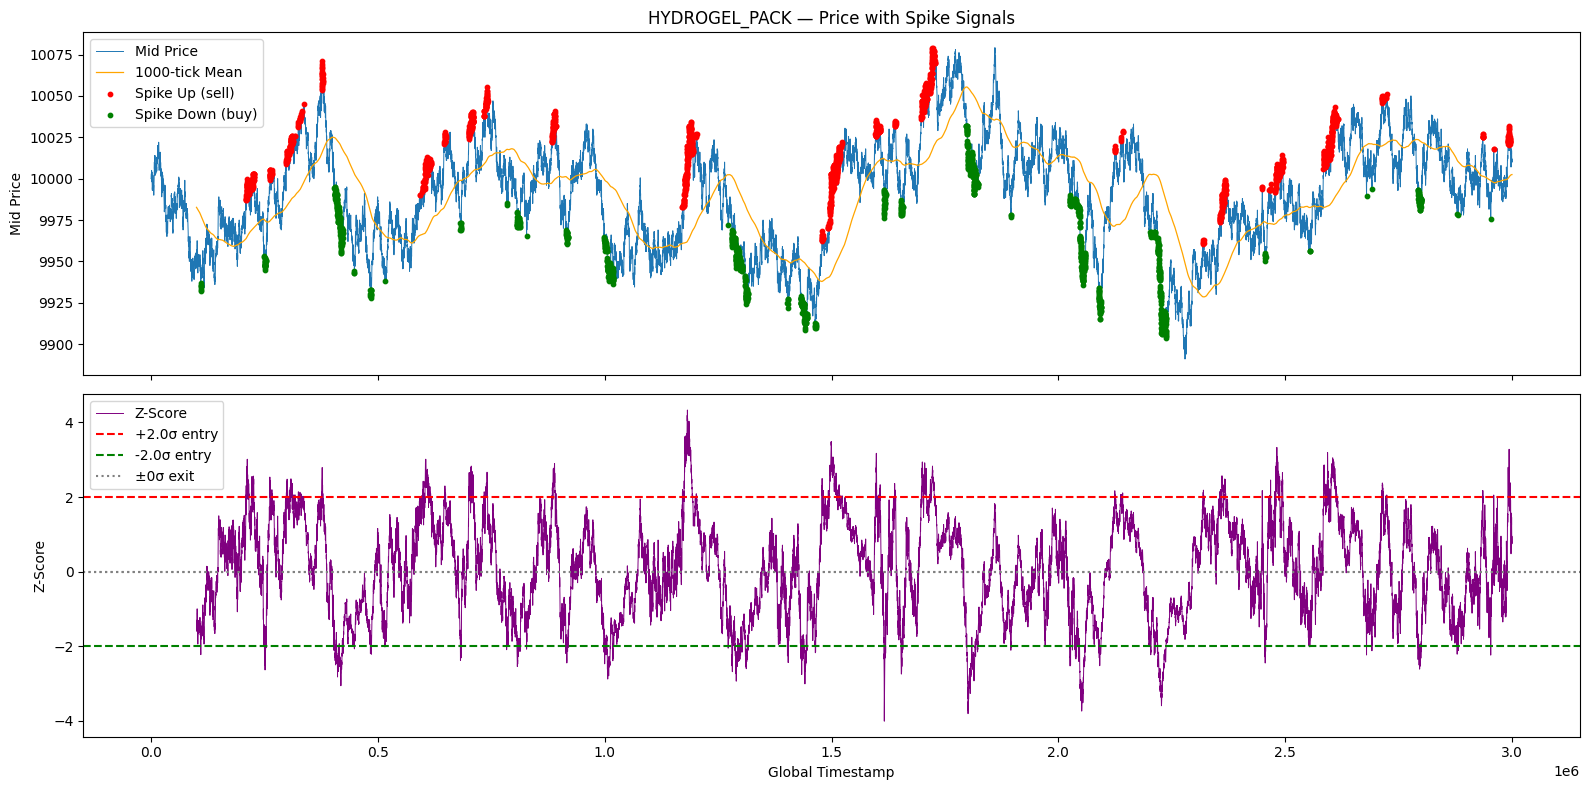

Total spike-up events:   1781
Total spike-down events: 1474


In [121]:
WINDOW = 1000
Z_ENTER = 2.0
Z_EXIT = 0

hg = product_dfs['HYDROGEL_PACK'].copy().reset_index(drop=True)
hg['rolling_mean'] = hg['mid_price'].rolling(WINDOW).mean()
hg['rolling_std']  = hg['mid_price'].rolling(WINDOW).std()
hg['z_score']      = (hg['mid_price'] - hg['rolling_mean']) / hg['rolling_std']

spike_up   = hg[hg['z_score'] >  Z_ENTER]
spike_down = hg[hg['z_score'] < -Z_ENTER]

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(hg['global_timestamp'], hg['mid_price'], linewidth=0.7, label='Mid Price')
axes[0].plot(hg['global_timestamp'], hg['rolling_mean'], linewidth=0.9, color='orange', label=f'{WINDOW}-tick Mean')
axes[0].scatter(spike_up['global_timestamp'],   spike_up['mid_price'],   color='red',   s=10, zorder=5, label='Spike Up (sell)')
axes[0].scatter(spike_down['global_timestamp'], spike_down['mid_price'], color='green', s=10, zorder=5, label='Spike Down (buy)')
axes[0].set_ylabel('Mid Price')
axes[0].set_title('HYDROGEL_PACK — Price with Spike Signals')
axes[0].legend()

axes[1].plot(hg['global_timestamp'], hg['z_score'], linewidth=0.7, color='purple', label='Z-Score')
axes[1].axhline( Z_ENTER, color='red',   linestyle='--', label=f'+{Z_ENTER}σ entry')
axes[1].axhline(-Z_ENTER, color='green', linestyle='--', label=f'-{Z_ENTER}σ entry')
axes[1].axhline( Z_EXIT,  color='gray',  linestyle=':',  label=f'±{Z_EXIT}σ exit')
axes[1].axhline(-Z_EXIT,  color='gray',  linestyle=':')
axes[1].set_ylabel('Z-Score')
axes[1].set_xlabel('Global Timestamp')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Total spike-up events:   {len(spike_up)}")
print(f"Total spike-down events: {len(spike_down)}")

In [124]:
POSITION_LIMIT = 50
Z_SCALE        = 3.0   # |z| at which target reaches full POSITION_LIMIT

days = hg['day'].values
zs   = hg['z_score'].values
bids = hg['bid_price_1'].values
asks = hg['ask_price_1'].values
mids = hg['mid_price'].values

position    = 0
cash        = 0.0
positions   = []
cash_history = []

for k in range(len(hg)):
    if k > 0 and days[k] != days[k - 1]:
        if position != 0:
            cash += position * mids[k - 1]
        position = 0

    z, bid, ask = zs[k], bids[k], asks[k]
    if np.isnan(z) or np.isnan(bid) or np.isnan(ask):
        positions.append(position)
        cash_history.append(cash)
        continue

    # Target: contrarian to z — higher |z| → larger position in the opposite direction
    if abs(z) < Z_EXIT:
        target = 0
    elif abs(z) < Z_ENTER:
        target = position  # hold — dead band, no new trades
    else:
        target = -int(np.clip(z / Z_SCALE * POSITION_LIMIT, -POSITION_LIMIT, POSITION_LIMIT))

    delta = target - position
    if delta > 0:
        cash     -= delta * ask   # buy at ask
        position += delta
    elif delta < 0:
        cash     += abs(delta) * bid  # sell at bid
        position += delta

    positions.append(position)
    cash_history.append(cash)

if position != 0:
    cash += position * mids[-1]

hg['position'] = positions
hg['cash']     = cash_history
hg['pnl']      = hg['cash'] + hg['position'] * hg['mid_price']

pnl_diff = hg['pnl'].diff().dropna()
sharpe   = pnl_diff.mean() / pnl_diff.std()

print(f"Final PnL (mark-to-market): {hg['pnl'].iloc[-1]:>12,.1f}")
print(f"Sharpe (per-tick):          {sharpe:>12.4f}")
print(f"Max drawdown:               {(hg['pnl'] - hg['pnl'].cummax()).min():>12,.1f}")
print(f"Total trades:               {(hg['position'].diff() != 0).sum():>12,}")

Final PnL (mark-to-market):    -18,065.0
Sharpe (per-tick):               -0.0081
Max drawdown:                  -25,856.0
Total trades:                      2,272


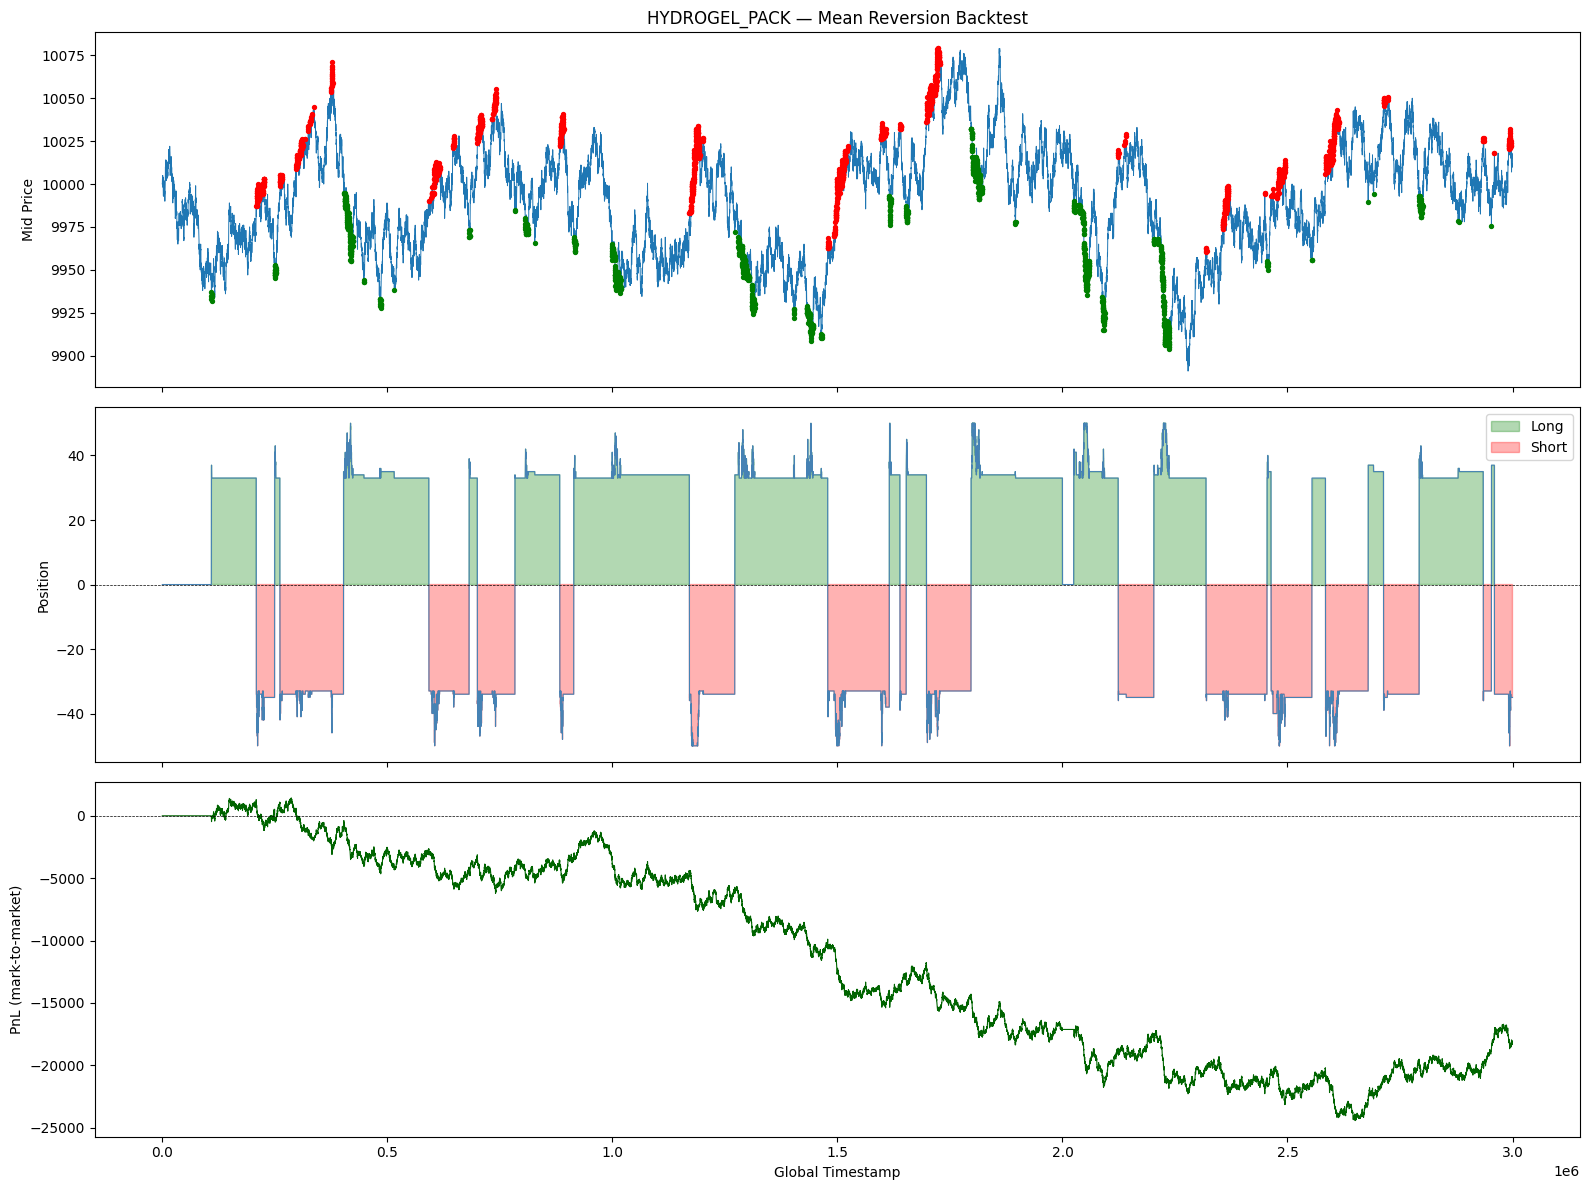

In [125]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

axes[0].plot(hg['global_timestamp'], hg['mid_price'], linewidth=0.7)
axes[0].scatter(spike_up['global_timestamp'],   spike_up['mid_price'],   color='red',   s=8, zorder=5)
axes[0].scatter(spike_down['global_timestamp'], spike_down['mid_price'], color='green', s=8, zorder=5)
axes[0].set_ylabel('Mid Price')
axes[0].set_title('HYDROGEL_PACK — Mean Reversion Backtest')

axes[1].plot(hg['global_timestamp'], hg['position'], linewidth=0.8, color='steelblue')
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].fill_between(hg['global_timestamp'], hg['position'], 0,
                     where=hg['position'] > 0, color='green', alpha=0.3, label='Long')
axes[1].fill_between(hg['global_timestamp'], hg['position'], 0,
                     where=hg['position'] < 0, color='red',   alpha=0.3, label='Short')
axes[1].set_ylabel('Position')
axes[1].legend()

axes[2].plot(hg['global_timestamp'], hg['pnl'], linewidth=0.8, color='darkgreen')
axes[2].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[2].set_ylabel('PnL (mark-to-market)')
axes[2].set_xlabel('Global Timestamp')

plt.tight_layout()
plt.show()

In [ ]:
2

In [69]:
Z_ENTER = 2.0
POSITION_LIMIT = 200

windows = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000]
z_exits = np.round(np.linspace(0.0, 1.0, 11), 2)

hg_base = product_dfs['HYDROGEL_PACK'][['day', 'mid_price', 'bid_price_1', 'ask_price_1']].copy().reset_index(drop=True)

def run_backtest(window, z_exit):
    hg = hg_base.copy()
    # Rolling stats per day to avoid cross-day contamination
    hg['rolling_mean'] = hg.groupby('day')['mid_price'].transform(lambda x: x.rolling(window).mean())
    hg['rolling_std']  = hg.groupby('day')['mid_price'].transform(lambda x: x.rolling(window).std())
    hg['z_score']      = (hg['mid_price'] - hg['rolling_mean']) / hg['rolling_std']

    days = hg['day'].values
    zs   = hg['z_score'].values
    bids = hg['bid_price_1'].values
    asks = hg['ask_price_1'].values
    mids = hg['mid_price'].values

    position = 0
    cash = 0.0
    current_day = days[0]

    for k in range(len(hg)):
        if days[k] != current_day:
            if position != 0:
                cash += position * mids[k - 1]  # close at last tick of previous day
            position = 0
            current_day = days[k]

        z, bid, ask = zs[k], bids[k], asks[k]
        if np.isnan(z) or np.isnan(bid) or np.isnan(ask):
            continue

        if z > Z_ENTER and position > -POSITION_LIMIT:
            qty = position + POSITION_LIMIT
            cash += qty * bid
            position -= qty
        elif z < -Z_ENTER and position < POSITION_LIMIT:
            qty = POSITION_LIMIT - position
            cash -= qty * ask
            position += qty

        if abs(z) < z_exit and position != 0:
            cash += position * bid if position > 0 else position * ask
            position = 0

    if position != 0:
        cash += position * mids[-1]

    return cash

pnl_grid = np.zeros((len(windows), len(z_exits)))
for i, w in enumerate(windows):
    for j, ze in enumerate(z_exits):
        pnl_grid[i, j] = run_backtest(w, ze)
    print(f"WINDOW={w:>5}  PnL range: [{pnl_grid[i].min():>10,.0f}, {pnl_grid[i].max():>10,.0f}]")

print("\nSweep complete.")

WINDOW=   10  PnL range: [-3,736,600, -1,678,800]
WINDOW=   20  PnL range: [-3,838,200, -1,687,200]
WINDOW=   50  PnL range: [-2,174,000,   -886,600]
WINDOW=  100  PnL range: [-1,236,200,   -439,000]
WINDOW=  200  PnL range: [  -636,000,   -162,600]
WINDOW=  500  PnL range: [  -210,200,     57,400]
WINDOW= 1000  PnL range: [   -76,600,     82,600]
WINDOW= 2000  PnL range: [     3,000,     64,800]
WINDOW= 5000  PnL range: [    16,400,     31,600]

Sweep complete.


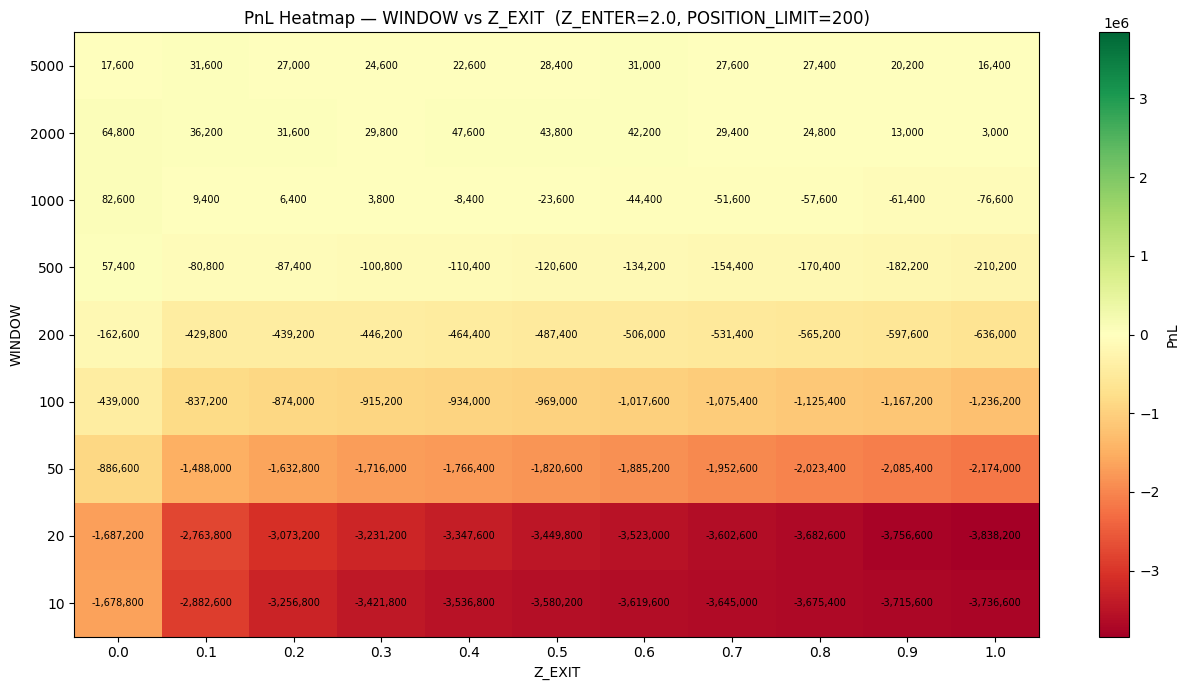

Best:  WINDOW=1000, Z_EXIT=0.0, PnL=82,600
Worst: WINDOW=20, Z_EXIT=1.0, PnL=-3,838,200


In [70]:
fig, ax = plt.subplots(figsize=(13, 7))

vmax = np.abs(pnl_grid).max()
im = ax.imshow(pnl_grid, aspect='auto', cmap='RdYlGn', origin='lower',
               vmin=-vmax, vmax=vmax)

ax.set_xticks(range(len(z_exits)))
ax.set_xticklabels(z_exits)
ax.set_yticks(range(len(windows)))
ax.set_yticklabels(windows)
ax.set_xlabel('Z_EXIT')
ax.set_ylabel('WINDOW')
ax.set_title(f'PnL Heatmap — WINDOW vs Z_EXIT  (Z_ENTER={Z_ENTER}, POSITION_LIMIT={POSITION_LIMIT})')

for i in range(len(windows)):
    for j in range(len(z_exits)):
        ax.text(j, i, f'{pnl_grid[i, j]:,.0f}', ha='center', va='center', fontsize=7,
                color='black')

plt.colorbar(im, ax=ax, label='PnL')
plt.tight_layout()
plt.show()

best = np.unravel_index(np.argmax(pnl_grid), pnl_grid.shape)
print(f"Best:  WINDOW={windows[best[0]]}, Z_EXIT={z_exits[best[1]]}, PnL={pnl_grid[best]:,.0f}")
worst = np.unravel_index(np.argmin(pnl_grid), pnl_grid.shape)
print(f"Worst: WINDOW={windows[worst[0]]}, Z_EXIT={z_exits[worst[1]]}, PnL={pnl_grid[worst]:,.0f}")

## Market-Making Strategy — Microprice Fair Value with Inventory Skew

Fair value = microprice = `(bid × ask_vol + ask × bid_vol) / (bid_vol + ask_vol)`.  
Inventory adjustment: `fair_adjusted = microprice − position × INVENTORY_SKEW` (skews quotes away from the risky side).  
We quote `[fair_adjusted − HALF_SPREAD, fair_adjusted + HALF_SPREAD]` and assume passive fills when the market crosses our quotes.

In [71]:
HALF_SPREAD    = 5     # half our quoted spread (market spread is ~16, so we're inside it)
INVENTORY_SKEW = 0.1  # price units of fair-value shift per unit of net position
POSITION_LIMIT = 50

hg = product_dfs['HYDROGEL_PACK'].copy().reset_index(drop=True)

days     = hg['day'].values
bids     = hg['bid_price_1'].values
asks     = hg['ask_price_1'].values
bid_vols = hg['bid_volume_1'].values
ask_vols = hg['ask_volume_1'].values
mids     = hg['mid_price'].values

position = 0
cash     = 0.0
pnl_history      = []
position_history = []

for k in range(len(hg)):
    # Close position at end of each day (competition resets daily)
    if k > 0 and days[k] != days[k - 1]:
        if position != 0:
            cash += position * mids[k - 1]
        position = 0

    bid, ask = bids[k], asks[k]
    bv,  av  = bid_vols[k], ask_vols[k]

    if np.isnan(bid) or np.isnan(ask) or np.isnan(bv) or np.isnan(av):
        pnl_history.append(cash + position * mids[k])
        position_history.append(position)
        continue

    # Standard microprice: weights bid by ask-side volume and vice versa.
    # High bid volume → price closer to ask (buying pressure), and the reverse.
    microprice = (bid * av + ask * bv) / (bv + av)

    # Skew fair value toward closing our position
    fair    = microprice - position * INVENTORY_SKEW
    our_bid = fair - HALF_SPREAD
    our_ask = fair + HALF_SPREAD

    # Passive buy fill: a seller in the market crosses our bid (their ask <= our bid)
    if ask <= our_bid and position < POSITION_LIMIT:
        qty       = min(int(av), POSITION_LIMIT - position)
        cash     -= qty * our_bid  # we pay our quoted bid price
        position += qty

    # Passive sell fill: a buyer in the market crosses our ask (their bid >= our ask)
    if bid >= our_ask and position > -POSITION_LIMIT:
        qty       = min(int(bv), position + POSITION_LIMIT)
        cash     += qty * our_ask  # we receive our quoted ask price
        position -= qty

    pnl_history.append(cash + position * mids[k])
    position_history.append(position)

# Mark final residual position to market
if position != 0:
    cash += position * mids[-1]

hg['position'] = position_history
hg['pnl']      = pnl_history

pnl_diff = hg['pnl'].diff().dropna()
sharpe   = pnl_diff.mean() / pnl_diff.std()  # per-tick, unannualized

print(f"Final PnL:            {hg['pnl'].iloc[-1]:>12,.1f}")
print(f"Sharpe (per-tick):    {sharpe:>12.4f}")
print(f"Max drawdown:         {(hg['pnl'] - hg['pnl'].cummax()).min():>12,.1f}")
print(f"Trades:               {(hg['position'].diff() != 0).sum():>12,}")

Final PnL:                     0.0
Sharpe (per-tick):             nan
Max drawdown:                  0.0
Trades:                          1


C:\Users\92028\AppData\Local\Temp\ipykernel_21552\4188951837.py:66: RuntimeWarning: invalid value encountered in scalar divide
  sharpe   = pnl_diff.mean() / pnl_diff.std()  # per-tick, unannualized


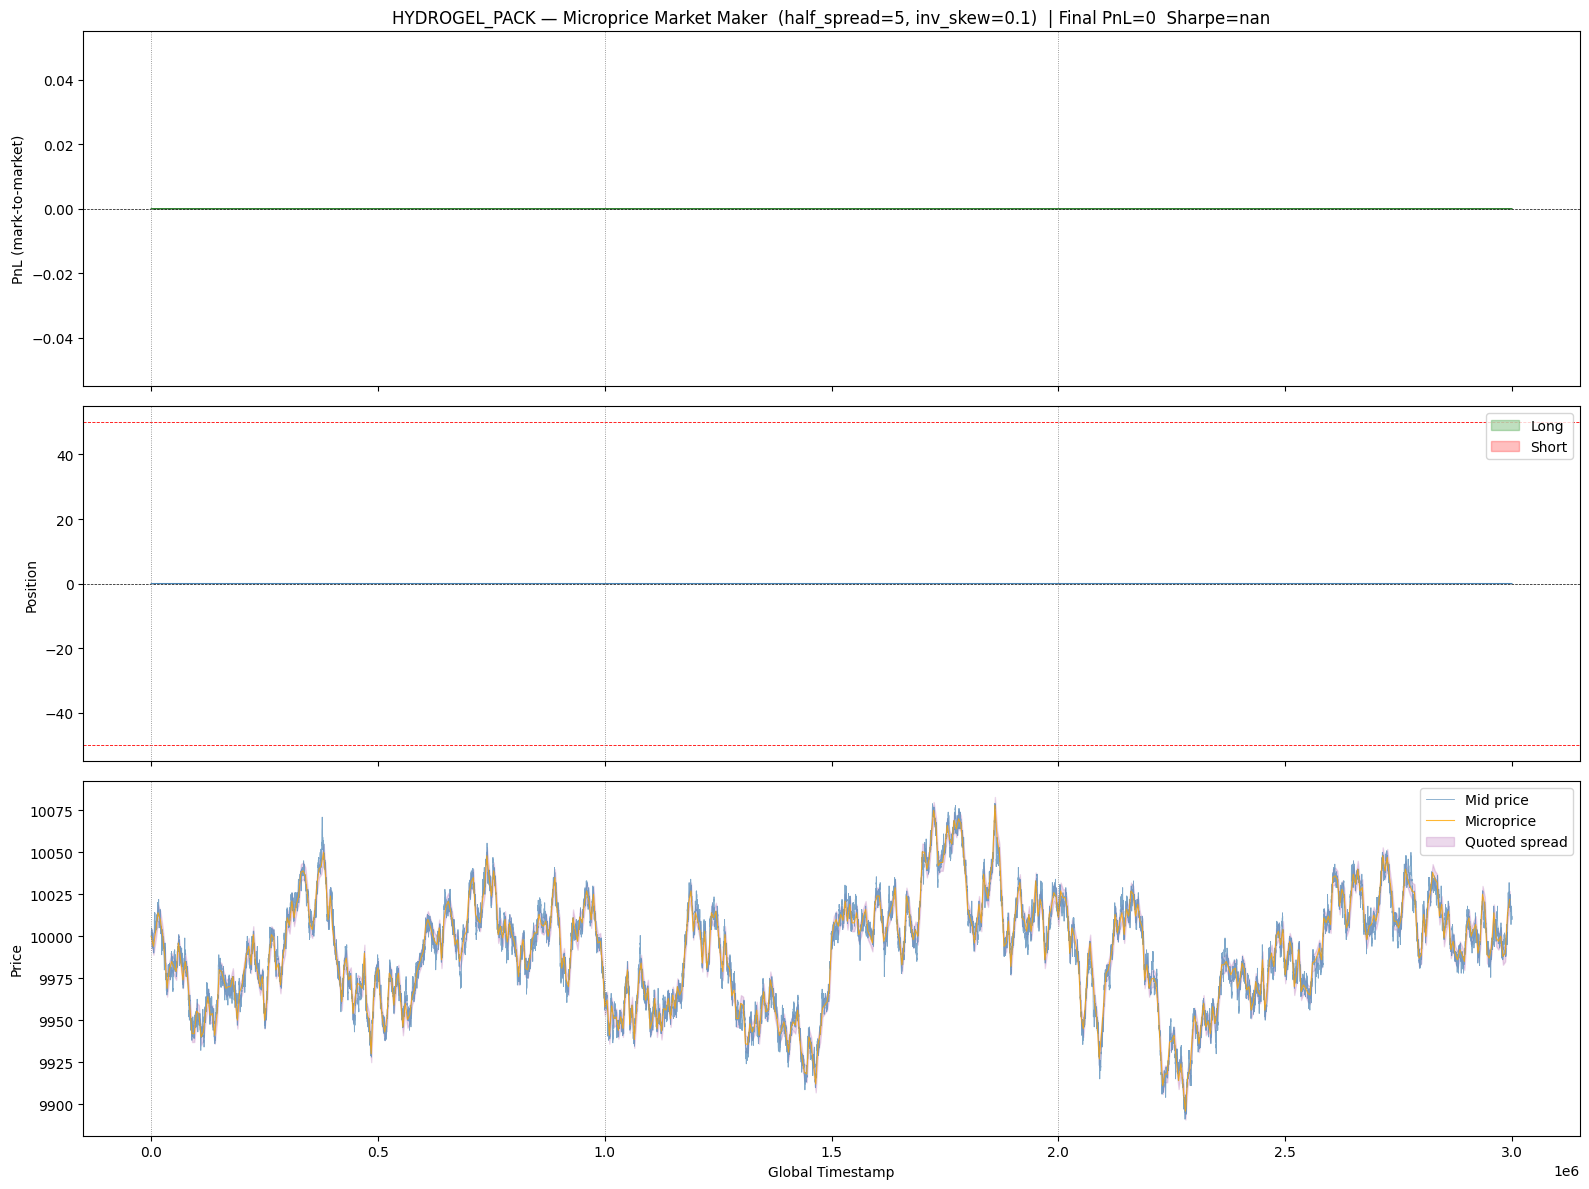

In [72]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# --- PnL ---
axes[0].plot(hg['global_timestamp'], hg['pnl'], linewidth=0.8, color='darkgreen')
axes[0].fill_between(hg['global_timestamp'], hg['pnl'], 0,
                     where=hg['pnl'] >= 0, color='green', alpha=0.15)
axes[0].fill_between(hg['global_timestamp'], hg['pnl'], 0,
                     where=hg['pnl'] < 0,  color='red',   alpha=0.15)
axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')
for day_start in hg[hg['timestamp'] == 0]['global_timestamp']:
    axes[0].axvline(day_start, color='gray', linewidth=0.6, linestyle=':')
axes[0].set_ylabel('PnL (mark-to-market)')
axes[0].set_title(
    f'HYDROGEL_PACK — Microprice Market Maker  '
    f'(half_spread={HALF_SPREAD}, inv_skew={INVENTORY_SKEW})  '
    f'| Final PnL={hg["pnl"].iloc[-1]:,.0f}  Sharpe={sharpe:.3f}'
)

# --- Position ---
axes[1].plot(hg['global_timestamp'], hg['position'], linewidth=0.8, color='steelblue')
axes[1].fill_between(hg['global_timestamp'], hg['position'], 0,
                     where=hg['position'] > 0, color='green', alpha=0.25, label='Long')
axes[1].fill_between(hg['global_timestamp'], hg['position'], 0,
                     where=hg['position'] < 0, color='red',   alpha=0.25, label='Short')
axes[1].axhline( POSITION_LIMIT,  color='red',   linewidth=0.6, linestyle='--')
axes[1].axhline(-POSITION_LIMIT,  color='red',   linewidth=0.6, linestyle='--')
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
for day_start in hg[hg['timestamp'] == 0]['global_timestamp']:
    axes[1].axvline(day_start, color='gray', linewidth=0.6, linestyle=':')
axes[1].set_ylabel('Position')
axes[1].legend(loc='upper right')

# --- Mid price + our quotes (sampled every 50 ticks for clarity) ---
sample = hg.iloc[::50].copy()
sample_micro = (sample['bid_price_1'] * sample['ask_volume_1'] + sample['ask_price_1'] * sample['bid_volume_1']) \
               / (sample['bid_volume_1'] + sample['ask_volume_1'])
sample_fair  = sample_micro - sample['position'] * INVENTORY_SKEW

axes[2].plot(hg['global_timestamp'], hg['mid_price'], linewidth=0.6, color='steelblue', label='Mid price', alpha=0.7)
axes[2].plot(sample['global_timestamp'], sample_micro, linewidth=0.8, color='orange', label='Microprice', alpha=0.8)
axes[2].fill_between(sample['global_timestamp'],
                     sample_fair - HALF_SPREAD,
                     sample_fair + HALF_SPREAD,
                     color='purple', alpha=0.15, label='Quoted spread')
for day_start in hg[hg['timestamp'] == 0]['global_timestamp']:
    axes[2].axvline(day_start, color='gray', linewidth=0.6, linestyle=':')
axes[2].set_ylabel('Price')
axes[2].set_xlabel('Global Timestamp')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

## Momentum Strategy — EMA Crossover with Volatility-Normalised Z-Score

**Momentum** = EMA(short) − EMA(long): positive when the short-term average is above the long-term average (uptrend), negative in a downtrend.  
**Z-score** = momentum / rolling volatility (std of price changes): normalises momentum by recent price noise so the threshold is comparable across different market regimes.  
**Entry**: z > Z_ENTER → go long; z < −Z_ENTER → go short. Trade in the *direction* of the signal (opposite to mean reversion).  
**Exit**: |z| < Z_EXIT (momentum has faded back toward zero).

In [115]:
SHORT_SPAN     = 5   # EMA short period (ticks)
LONG_SPAN      = 10   # EMA long period (ticks)
VOL_WINDOW     = 50   # rolling window for volatility (std of price changes)
Z_ENTER        = 2   # minimum |z| to hold any position
Z_SCALE        = 5.0   # |z| at which target reaches full POSITION_LIMIT
Z_EXIT         = 0.2   # |z| below which we force-close entirely
POSITION_LIMIT = 100

hg = product_dfs['HYDROGEL_PACK'].copy().reset_index(drop=True)

# All indicators computed per day to avoid cross-day contamination
hg['ema_short']    = hg.groupby('day')['mid_price'].transform(
                         lambda x: x.ewm(span=SHORT_SPAN, adjust=False).mean())
hg['ema_long']     = hg.groupby('day')['mid_price'].transform(
                         lambda x: x.ewm(span=LONG_SPAN, adjust=False).mean())
hg['momentum']     = hg['ema_short'] - hg['ema_long']
hg['price_change'] = hg.groupby('day')['mid_price'].transform(lambda x: x.diff())
hg['volatility']   = hg.groupby('day')['price_change'].transform(
                         lambda x: x.rolling(VOL_WINDOW).std())
hg['z_score']      = hg['momentum'] / hg['volatility']

days = hg['day'].values
zs   = hg['z_score'].values
bids = hg['bid_price_1'].values
asks = hg['ask_price_1'].values
mids = hg['mid_price'].values

position     = 0
cash         = 0.0
pnl_history  = []
pos_history  = []
tgt_history  = []

for k in range(len(hg)):
    if k > 0 and days[k] != days[k - 1]:
        if position != 0:
            cash += position * mids[k - 1]
        position = 0

    z, bid, ask = zs[k], bids[k], asks[k]
    if np.isnan(z) or np.isnan(bid) or np.isnan(ask):
        pnl_history.append(cash + position * mids[k])
        pos_history.append(position)
        tgt_history.append(0)
        continue

    # Target position: linearly proportional to z, capped at ±POSITION_LIMIT.
    # Zero below Z_ENTER (dead band to avoid noise trading).
    # Force zero when |z| < Z_EXIT (momentum has fully faded).
    if abs(z) < Z_EXIT:
        target = 0
    elif abs(z) < Z_ENTER:
        target = position  # hold — don't add but don't exit yet
    else:
        target = int(np.clip(z / Z_SCALE * POSITION_LIMIT, -POSITION_LIMIT, POSITION_LIMIT))

    tgt_history.append(target)

    delta = target - position
    if delta > 0:
        cash     -= delta * ask   # buy delta units at ask
        position += delta
    elif delta < 0:
        cash     += abs(delta) * bid  # sell |delta| units at bid
        position += delta

    pnl_history.append(cash + position * mids[k])
    pos_history.append(position)

if position != 0:
    cash += position * mids[-1]

hg['pnl']      = pnl_history
hg['position'] = pos_history
hg['target']   = tgt_history

pnl_diff = hg['pnl'].diff().dropna()
sharpe   = pnl_diff.mean() / pnl_diff.std()

print(f"Final PnL:         {hg['pnl'].iloc[-1]:>12,.1f}")
print(f"Sharpe (per-tick): {sharpe:>12.4f}")
print(f"Max drawdown:      {(hg['pnl'] - hg['pnl'].cummax()).min():>12,.1f}")
print(f"Trades:            {(hg['position'].diff() != 0).sum():>12,}")

Final PnL:             -4,917.0
Sharpe (per-tick):      -0.0211
Max drawdown:          -4,917.0
Trades:                      14


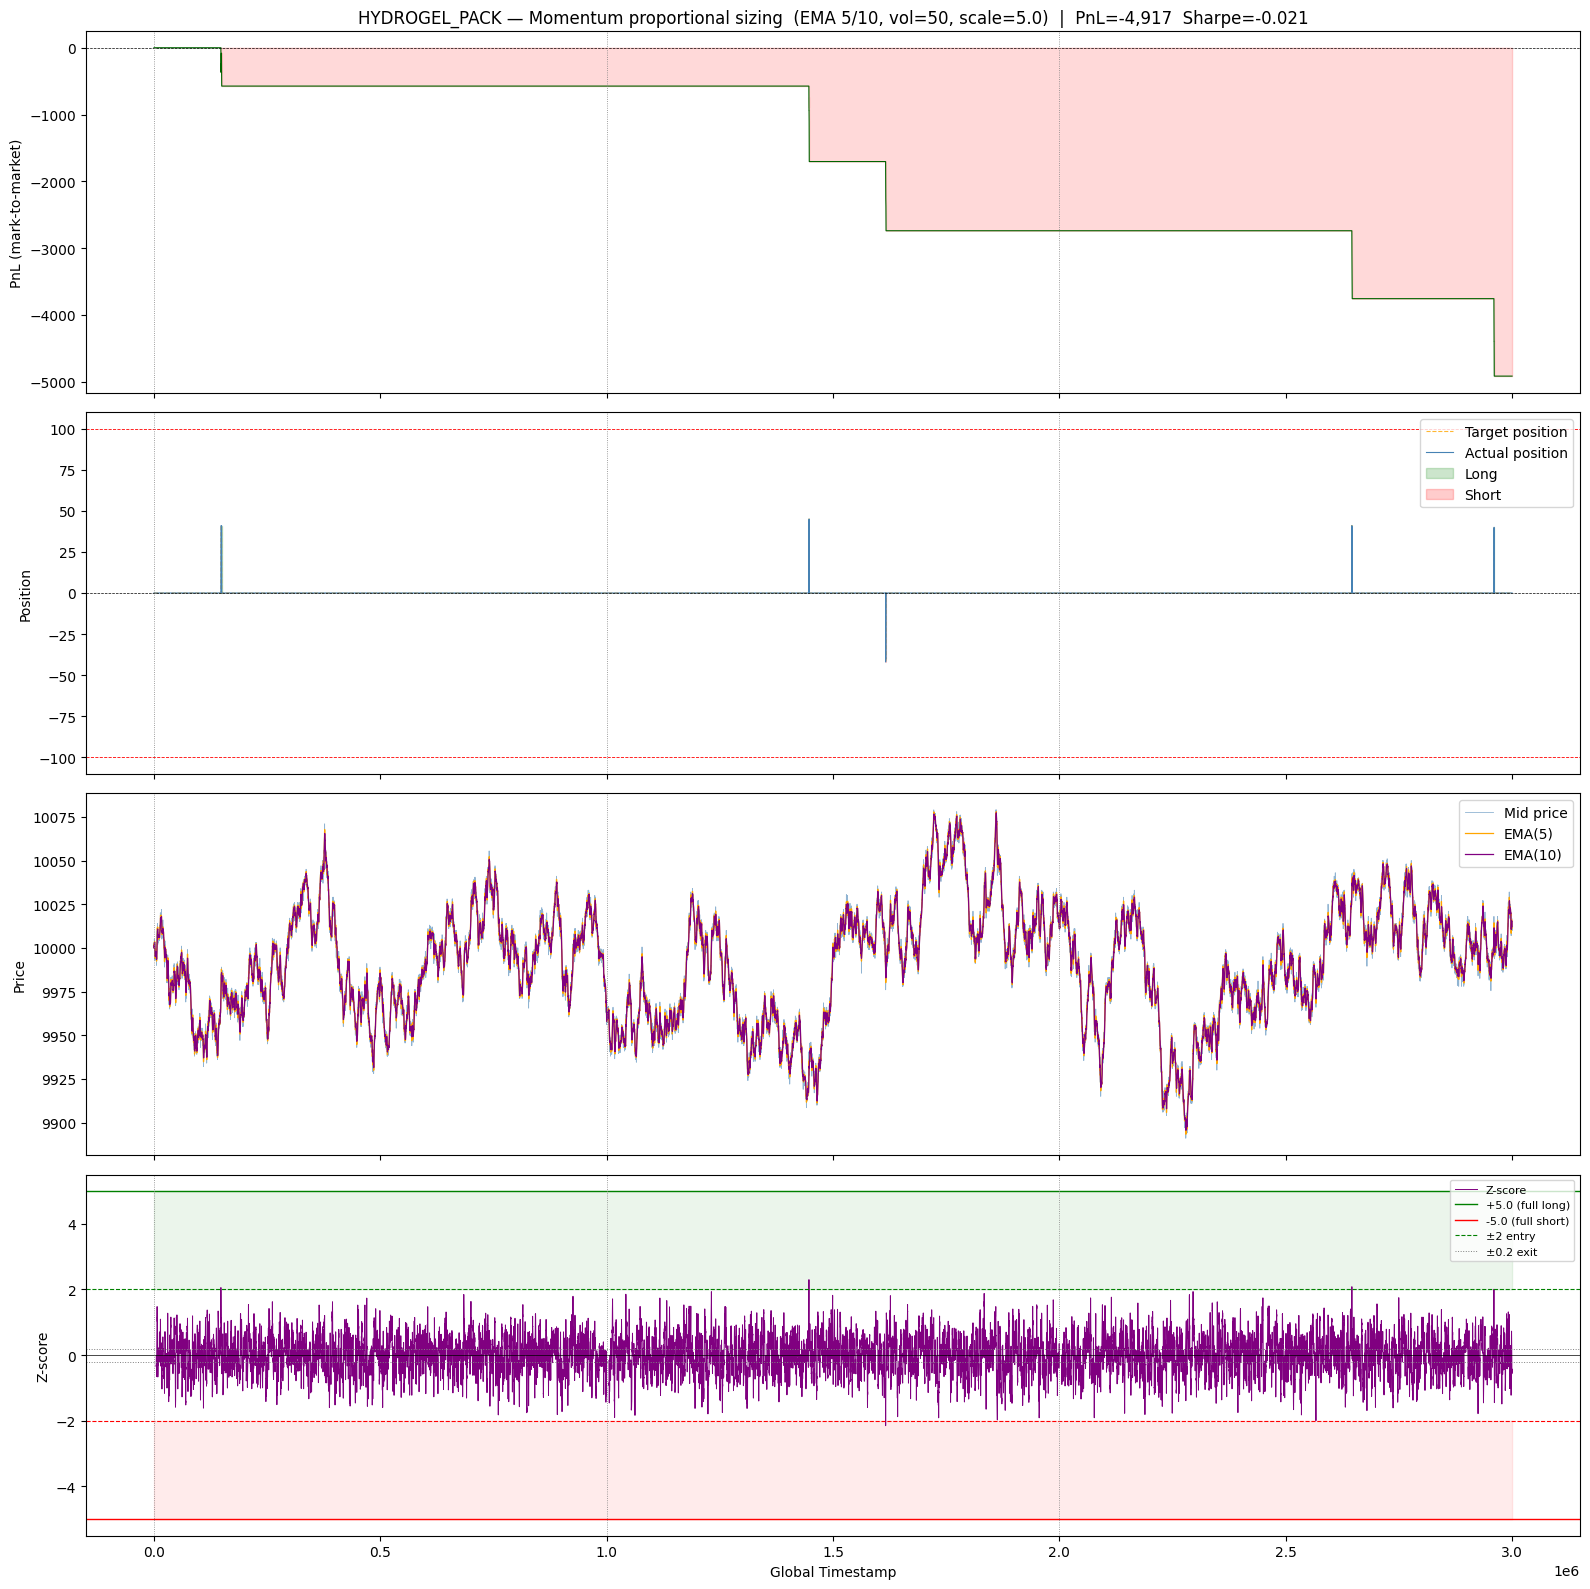

In [116]:
fig, axes = plt.subplots(4, 1, figsize=(16, 16), sharex=True)

day_starts = hg[hg['timestamp'] == 0]['global_timestamp']

# --- PnL ---
axes[0].plot(hg['global_timestamp'], hg['pnl'], linewidth=0.8, color='darkgreen')
axes[0].fill_between(hg['global_timestamp'], hg['pnl'], 0,
                     where=hg['pnl'] >= 0, color='green', alpha=0.15)
axes[0].fill_between(hg['global_timestamp'], hg['pnl'], 0,
                     where=hg['pnl'] <  0, color='red',   alpha=0.15)
axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')
for d in day_starts: axes[0].axvline(d, color='gray', linewidth=0.6, linestyle=':')
axes[0].set_ylabel('PnL (mark-to-market)')
axes[0].set_title(
    f'HYDROGEL_PACK — Momentum proportional sizing  '
    f'(EMA {SHORT_SPAN}/{LONG_SPAN}, vol={VOL_WINDOW}, scale={Z_SCALE})  |  '
    f'PnL={hg["pnl"].iloc[-1]:,.0f}  Sharpe={sharpe:.3f}'
)

# --- Position vs target ---
axes[1].plot(hg['global_timestamp'], hg['target'],   linewidth=0.8, color='orange',
             linestyle='--', alpha=0.8, label='Target position')
axes[1].plot(hg['global_timestamp'], hg['position'], linewidth=0.8, color='steelblue',
             label='Actual position')
axes[1].fill_between(hg['global_timestamp'], hg['position'], 0,
                     where=hg['position'] > 0, color='green', alpha=0.2, label='Long')
axes[1].fill_between(hg['global_timestamp'], hg['position'], 0,
                     where=hg['position'] < 0, color='red',   alpha=0.2, label='Short')
axes[1].axhline( POSITION_LIMIT, color='red', linewidth=0.6, linestyle='--')
axes[1].axhline(-POSITION_LIMIT, color='red', linewidth=0.6, linestyle='--')
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
for d in day_starts: axes[1].axvline(d, color='gray', linewidth=0.6, linestyle=':')
axes[1].set_ylabel('Position')
axes[1].legend(loc='upper right')

# --- EMA crossover ---
axes[2].plot(hg['global_timestamp'], hg['mid_price'], linewidth=0.6, color='steelblue',
             alpha=0.6, label='Mid price')
axes[2].plot(hg['global_timestamp'], hg['ema_short'], linewidth=0.9, color='orange',
             label=f'EMA({SHORT_SPAN})')
axes[2].plot(hg['global_timestamp'], hg['ema_long'],  linewidth=0.9, color='purple',
             label=f'EMA({LONG_SPAN})')
for d in day_starts: axes[2].axvline(d, color='gray', linewidth=0.6, linestyle=':')
axes[2].set_ylabel('Price')
axes[2].legend(loc='upper right')

# --- Z-score with proportional sizing bands ---
axes[3].plot(hg['global_timestamp'], hg['z_score'], linewidth=0.7, color='purple',
             label='Z-score')
# shade the region where position is proportionally scaled
axes[3].fill_between(hg['global_timestamp'], Z_ENTER, Z_SCALE,  alpha=0.08, color='green')
axes[3].fill_between(hg['global_timestamp'], -Z_SCALE, -Z_ENTER, alpha=0.08, color='red')
axes[3].axhline( Z_SCALE,  color='green', linewidth=1.0, linestyle='-',
                label=f'+{Z_SCALE} (full long)')
axes[3].axhline(-Z_SCALE,  color='red',   linewidth=1.0, linestyle='-',
                label=f'-{Z_SCALE} (full short)')
axes[3].axhline( Z_ENTER,  color='green', linewidth=0.8, linestyle='--',
                label=f'±{Z_ENTER} entry')
axes[3].axhline(-Z_ENTER,  color='red',   linewidth=0.8, linestyle='--')
axes[3].axhline( Z_EXIT,   color='gray',  linewidth=0.7, linestyle=':',
                label=f'±{Z_EXIT} exit')
axes[3].axhline(-Z_EXIT,   color='gray',  linewidth=0.7, linestyle=':')
axes[3].axhline(0, color='black', linewidth=0.5)
for d in day_starts: axes[3].axvline(d, color='gray', linewidth=0.6, linestyle=':')
axes[3].set_ylabel('Z-score')
axes[3].set_xlabel('Global Timestamp')
axes[3].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

In [119]:
# Fixed parameters for the sweep
VOL_WINDOW     = 100
Z_ENTER        = 2.0
Z_SCALE        = 5.0
Z_EXIT         = 0
POSITION_LIMIT = 100

spans = [1,2,5,10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000]

hg_sweep = product_dfs['HYDROGEL_PACK'][
    ['day', 'mid_price', 'bid_price_1', 'ask_price_1']
].copy().reset_index(drop=True)

# Precompute EMA for every span once — reused across all (short, long) pairs
ema_cache = {}
for s in spans:
    ema_cache[s] = hg_sweep.groupby('day')['mid_price'].transform(
        lambda x, sp=s: x.ewm(span=sp, adjust=False).mean()
    ).values

# Precompute volatility once — independent of EMA spans
_tmp        = hg_sweep.copy()
_tmp['pc']  = _tmp.groupby('day')['mid_price'].transform(lambda x: x.diff())
_tmp['vol'] = _tmp.groupby('day')['pc'].transform(lambda x: x.rolling(VOL_WINDOW).std())
vol_arr     = _tmp['vol'].values

days_arr = hg_sweep['day'].values
bids_arr = hg_sweep['bid_price_1'].values
asks_arr = hg_sweep['ask_price_1'].values
mids_arr = hg_sweep['mid_price'].values

def run_momentum_sweep(z_arr):
    position = 0
    cash     = 0.0
    for k in range(len(z_arr)):
        if k > 0 and days_arr[k] != days_arr[k - 1]:
            if position != 0:
                cash += position * mids_arr[k - 1]
            position = 0
        z, bid, ask = z_arr[k], bids_arr[k], asks_arr[k]
        if np.isnan(z) or np.isnan(bid) or np.isnan(ask):
            continue
        if abs(z) < Z_EXIT:
            target = 0
        elif abs(z) < Z_ENTER:
            target = position
        else:
            target = int(np.clip(z / Z_SCALE * POSITION_LIMIT, -POSITION_LIMIT, POSITION_LIMIT))
        delta = target - position
        if delta > 0:
            cash -= delta * ask
            position += delta
        elif delta < 0:
            cash += abs(delta) * bid
            position += delta
    if position != 0:
        cash += position * mids_arr[-1]
    return cash

n = len(spans)
# rows = LONG_SPAN index, cols = SHORT_SPAN index; NaN where short >= long (invalid)
pnl_mom_grid = np.full((n, n), np.nan)

for i, long_span in enumerate(spans):
    for j, short_span in enumerate(spans):
        if short_span >= long_span:
            continue
        momentum             = ema_cache[short_span] - ema_cache[long_span]
        z_arr                = np.where(vol_arr > 0, momentum / vol_arr, np.nan)
        pnl_mom_grid[i, j]   = run_momentum_sweep(z_arr)
    print(f"long={long_span:>6}  best so far: {np.nanmax(pnl_mom_grid):>10,.0f}")

print("\nSweep complete.")

C:\Users\92028\AppData\Local\Temp\ipykernel_21552\3982659942.py:71: RuntimeWarning: All-NaN slice encountered
  print(f"long={long_span:>6}  best so far: {np.nanmax(pnl_mom_grid):>10,.0f}")


long=     1  best so far:        nan
long=     2  best so far:          0
long=     5  best so far:          0
long=    10  best so far:          0
long=    20  best so far:          0
long=    50  best so far:          0
long=   100  best so far:          0
long=   200  best so far:          0
long=   500  best so far:          0
long=  1000  best so far:          0
long=  2000  best so far:          0
long=  5000  best so far:          0
long= 10000  best so far:          0

Sweep complete.


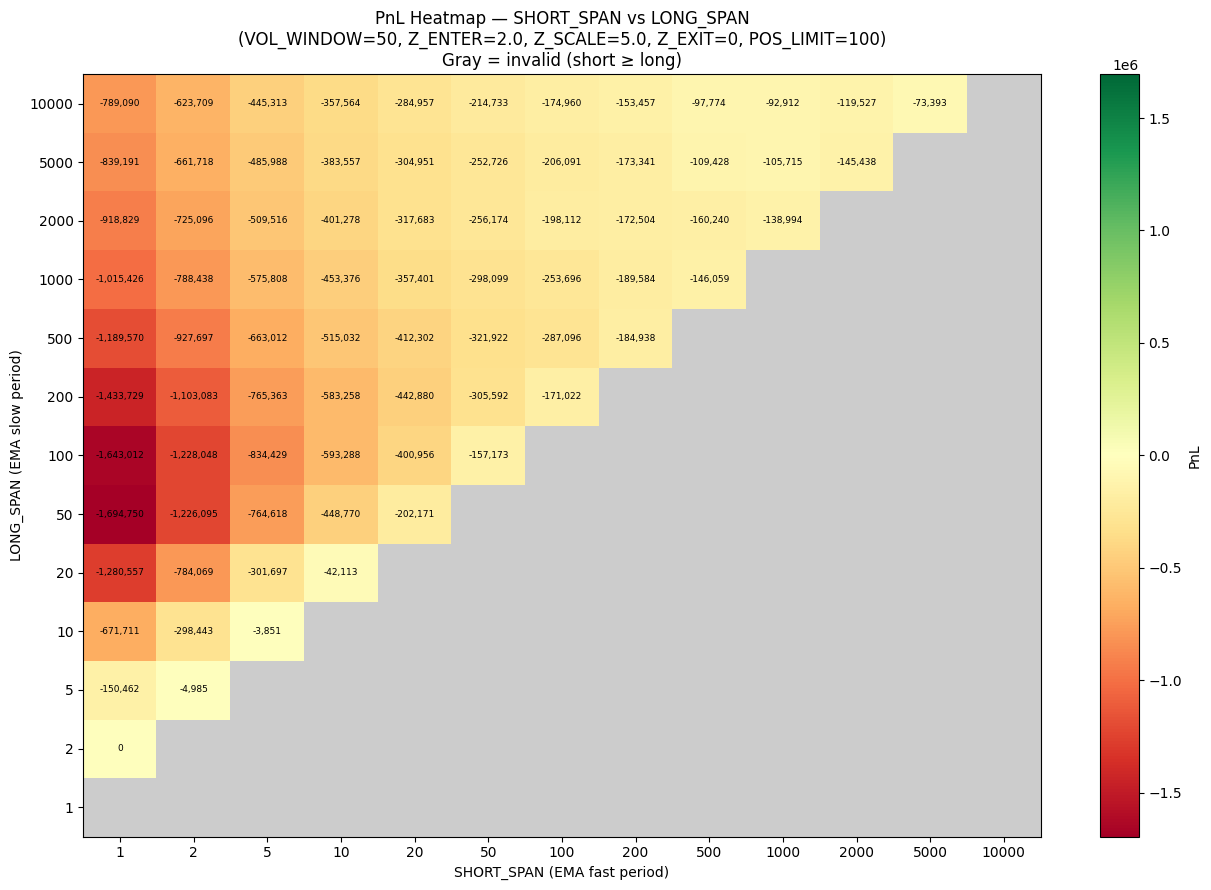

Best:  SHORT=1, LONG=2, PnL=0
Worst: SHORT=1, LONG=50, PnL=-1,694,750


In [118]:
fig, ax = plt.subplots(figsize=(13, 9))

# Mask invalid cells (short >= long) so they render as gray
masked = np.ma.masked_invalid(pnl_mom_grid)
cmap   = plt.cm.RdYlGn.copy()
cmap.set_bad(color='#cccccc')

vmax = np.nanmax(np.abs(pnl_mom_grid))
im   = ax.imshow(masked, aspect='auto', cmap=cmap, origin='lower',
                 vmin=-vmax, vmax=vmax)

span_labels = [str(s) for s in spans]
ax.set_xticks(range(n))
ax.set_xticklabels(span_labels)
ax.set_yticks(range(n))
ax.set_yticklabels(span_labels)
ax.set_xlabel('SHORT_SPAN (EMA fast period)')
ax.set_ylabel('LONG_SPAN (EMA slow period)')
ax.set_title(
    f'PnL Heatmap — SHORT_SPAN vs LONG_SPAN\n'
    f'(VOL_WINDOW={VOL_WINDOW}, Z_ENTER={Z_ENTER}, Z_SCALE={Z_SCALE}, '
    f'Z_EXIT={Z_EXIT}, POS_LIMIT={POSITION_LIMIT})\n'
    f'Gray = invalid (short ≥ long)'
)

for i in range(n):
    for j in range(n):
        v = pnl_mom_grid[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:,.0f}', ha='center', va='center', fontsize=6.5)

plt.colorbar(im, ax=ax, label='PnL')
plt.tight_layout()
plt.show()

best  = np.unravel_index(np.nanargmax(pnl_mom_grid), pnl_mom_grid.shape)
worst = np.unravel_index(np.nanargmin(pnl_mom_grid), pnl_mom_grid.shape)
print(f"Best:  SHORT={spans[best[1]]}, LONG={spans[best[0]]}, PnL={pnl_mom_grid[best]:,.0f}")
print(f"Worst: SHORT={spans[worst[1]]}, LONG={spans[worst[0]]}, PnL={pnl_mom_grid[worst]:,.0f}")

## Regime-Switching Strategy — Momentum + Mean Reversion

**Regime detector**: `momentum_strength = (price − price[k − LOOKBACK]) / volatility`  
A large |momentum_strength| means the market has been trending strongly → use the **momentum** strategy.  
A small |momentum_strength| means the market is ranging → use the **mean reversion** strategy.

Both sub-strategies use the same proportional z-score sizing; they differ only in signal direction:
- Momentum: `target = +clip(z_mom / Z_SCALE_MOM × limit, ±limit)`  
- Mean reversion: `target = −clip(z_rev / Z_SCALE_REV × limit, ±limit)`

In [138]:
# --- Regime detector ---
LOOKBACK         = 1     # ticks back for momentum strength measurement
REGIME_THRESHOLD = 3.0    # |momentum_strength| above this → momentum regime

# --- Momentum sub-strategy ---
SHORT_SPAN       = 10
LONG_SPAN        = 20
Z_SCALE_MOM      = 3.0

# --- Mean reversion sub-strategy ---
MR_WINDOW        = 1000
Z_SCALE_REV      = 4.0

# --- Shared ---
VOL_WINDOW       = 500
Z_ENTER          = 1.0
Z_EXIT           = 0.1
POSITION_LIMIT   = 50

hg = product_dfs['HYDROGEL_PACK'].copy().reset_index(drop=True)

# All indicators computed per day to avoid cross-day contamination
hg['price_change'] = hg.groupby('day')['mid_price'].transform(lambda x: x.diff())
hg['volatility']   = hg.groupby('day')['price_change'].transform(
                         lambda x: x.rolling(VOL_WINDOW).std())

# Regime: raw price momentum over LOOKBACK ticks, normalised by volatility
hg['price_lag']    = hg.groupby('day')['mid_price'].transform(lambda x: x.shift(LOOKBACK))
hg['mom_strength'] = (hg['mid_price'] - hg['price_lag']) / hg['volatility']

# Momentum z-score: EMA crossover
hg['ema_short']    = hg.groupby('day')['mid_price'].transform(
                         lambda x: x.ewm(span=SHORT_SPAN, adjust=False).mean())
hg['ema_long']     = hg.groupby('day')['mid_price'].transform(
                         lambda x: x.ewm(span=LONG_SPAN, adjust=False).mean())
hg['z_mom']        = (hg['ema_short'] - hg['ema_long']) / hg['volatility']

# Mean reversion z-score: rolling mean deviation
hg['roll_mean']    = hg.groupby('day')['mid_price'].transform(
                         lambda x: x.rolling(MR_WINDOW).mean())
hg['roll_std']     = hg.groupby('day')['mid_price'].transform(
                         lambda x: x.rolling(MR_WINDOW).std())
hg['z_rev']        = (hg['mid_price'] - hg['roll_mean']) / hg['roll_std']

days    = hg['day'].values
ms_arr  = hg['mom_strength'].values
zmom    = hg['z_mom'].values
zrev    = hg['z_rev'].values
bids    = hg['bid_price_1'].values
asks    = hg['ask_price_1'].values
mids    = hg['mid_price'].values

position     = 0
cash         = 0.0
pnl_history  = []
pos_history  = []
regime_history = []   # 1 = momentum, -1 = mean reversion, 0 = no signal

for k in range(len(hg)):
    if k > 0 and days[k] != days[k - 1]:
        if position != 0:
            cash += position * mids[k - 1]
        position = 0

    ms, zm, zr = ms_arr[k], zmom[k], zrev[k]
    bid, ask   = bids[k], asks[k]

    if np.isnan(ms) or np.isnan(bid) or np.isnan(ask):
        pnl_history.append(cash + position * mids[k])
        pos_history.append(position)
        regime_history.append(0)
        continue

    if abs(ms) > REGIME_THRESHOLD:
        # --- Momentum regime ---
        regime_history.append(1)
        z = zm
        if np.isnan(z) or abs(z) < Z_EXIT:
            target = 0
        elif abs(z) < Z_ENTER:
            target = position
        else:
            target = int(np.clip(z / Z_SCALE_MOM * POSITION_LIMIT, -POSITION_LIMIT, POSITION_LIMIT))
    else:
        # --- Mean reversion regime ---
        regime_history.append(-1)
        z = zr
        if np.isnan(z) or abs(z) < Z_EXIT:
            target = 0
        elif abs(z) < Z_ENTER:
            target = position
        else:
            target = -int(np.clip(z / Z_SCALE_REV * POSITION_LIMIT, -POSITION_LIMIT, POSITION_LIMIT))

    delta = target - position
    if delta > 0:
        cash     -= delta * ask
        position += delta
    elif delta < 0:
        cash     += abs(delta) * bid
        position += delta

    pnl_history.append(cash + position * mids[k])
    pos_history.append(position)

if position != 0:
    cash += position * mids[-1]

hg['pnl']    = pnl_history
hg['position'] = pos_history
hg['regime'] = regime_history   # 1=momentum, -1=mean reversion, 0=no data

pnl_diff = hg['pnl'].diff().dropna()
sharpe   = pnl_diff.mean() / pnl_diff.std()

mom_pct = (hg['regime'] == 1).mean() * 100
rev_pct = (hg['regime'] == -1).mean() * 100

print(f"Final PnL:             {hg['pnl'].iloc[-1]:>12,.1f}")
print(f"Sharpe (per-tick):     {sharpe:>12.4f}")
print(f"Max drawdown:          {(hg['pnl'] - hg['pnl'].cummax()).min():>12,.1f}")
print(f"Trades:                {(hg['position'].diff() != 0).sum():>12,}")
print(f"Momentum regime:       {mom_pct:>11.1f}%")
print(f"Mean reversion regime: {rev_pct:>11.1f}%")

Final PnL:               -131,303.0
Sharpe (per-tick):          -0.1199
Max drawdown:            -131,368.0
Trades:                       9,482
Momentum regime:               0.6%
Mean reversion regime:        94.4%


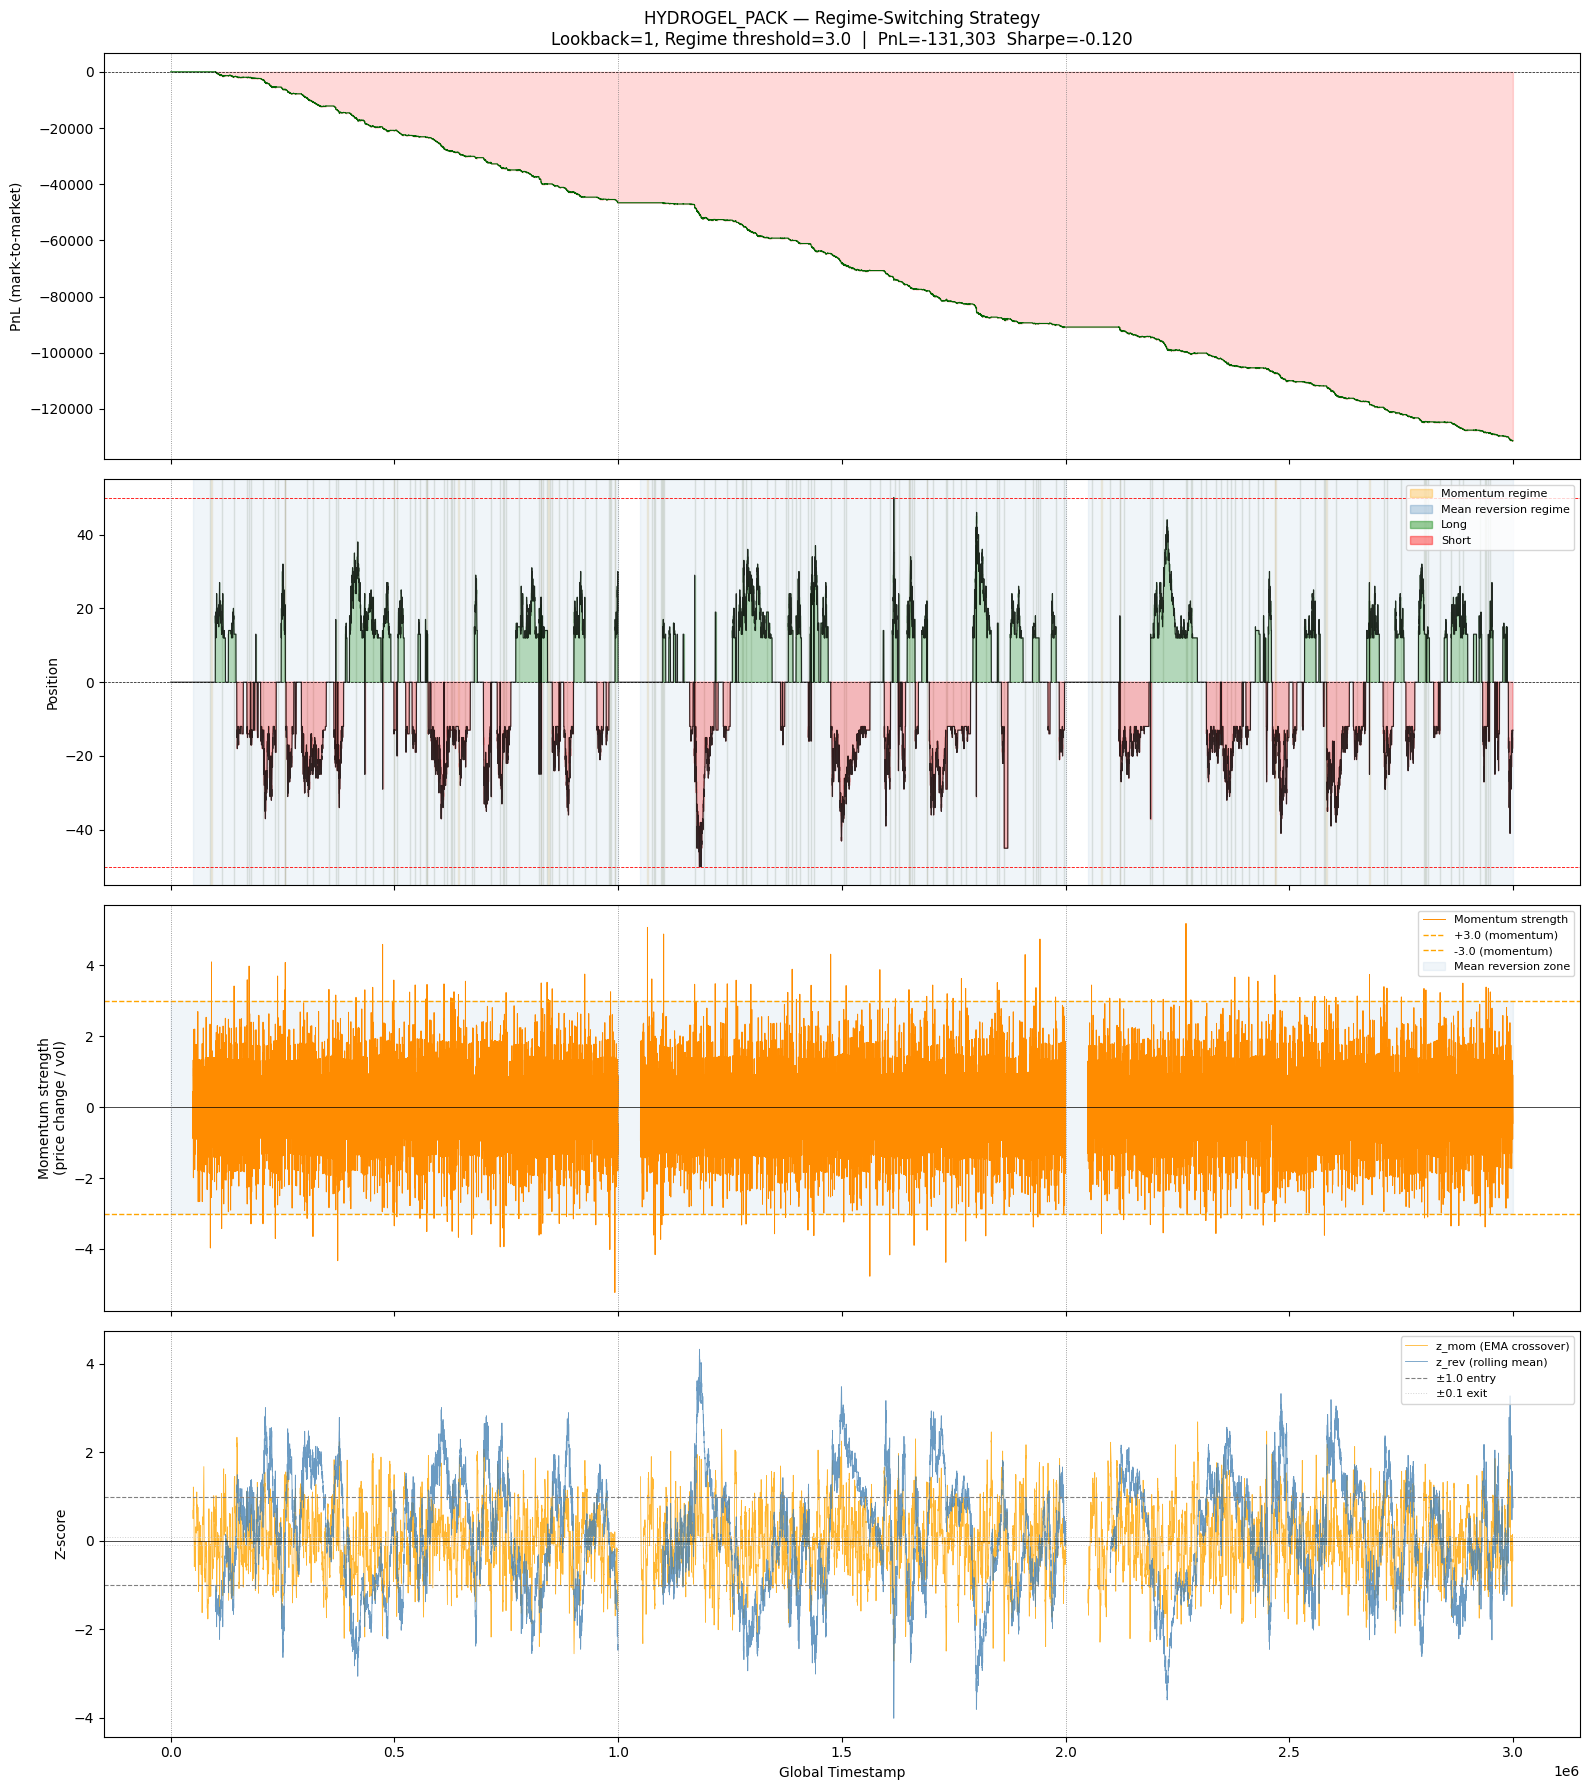

In [139]:
fig, axes = plt.subplots(4, 1, figsize=(16, 18), sharex=True)

day_starts = hg[hg['timestamp'] == 0]['global_timestamp']

# --- PnL ---
axes[0].plot(hg['global_timestamp'], hg['pnl'], linewidth=0.8, color='darkgreen')
axes[0].fill_between(hg['global_timestamp'], hg['pnl'], 0,
                     where=hg['pnl'] >= 0, color='green', alpha=0.15)
axes[0].fill_between(hg['global_timestamp'], hg['pnl'], 0,
                     where=hg['pnl'] <  0, color='red',   alpha=0.15)
axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')
for d in day_starts: axes[0].axvline(d, color='gray', linewidth=0.6, linestyle=':')
axes[0].set_ylabel('PnL (mark-to-market)')
axes[0].set_title(
    f'HYDROGEL_PACK — Regime-Switching Strategy\n'
    f'Lookback={LOOKBACK}, Regime threshold={REGIME_THRESHOLD}  |  '
    f'PnL={hg["pnl"].iloc[-1]:,.0f}  Sharpe={sharpe:.3f}'
)

# --- Position with regime shading ---
# Shade background: orange = momentum regime, blue = mean reversion regime
for d_start, d_end in zip(
    hg[hg['regime'] != hg['regime'].shift()].index,
    list(hg[hg['regime'] != hg['regime'].shift()].index[1:]) + [len(hg) - 1]
):
    r = hg['regime'].iloc[d_start]
    t0 = hg['global_timestamp'].iloc[d_start]
    t1 = hg['global_timestamp'].iloc[d_end]
    if r == 1:
        axes[1].axvspan(t0, t1, alpha=0.08, color='orange')
    elif r == -1:
        axes[1].axvspan(t0, t1, alpha=0.08, color='steelblue')

axes[1].plot(hg['global_timestamp'], hg['position'], linewidth=0.8, color='black', alpha=0.8)
axes[1].fill_between(hg['global_timestamp'], hg['position'], 0,
                     where=hg['position'] > 0, color='green', alpha=0.25, label='Long')
axes[1].fill_between(hg['global_timestamp'], hg['position'], 0,
                     where=hg['position'] < 0, color='red',   alpha=0.25, label='Short')
axes[1].axhline( POSITION_LIMIT, color='red', linewidth=0.6, linestyle='--')
axes[1].axhline(-POSITION_LIMIT, color='red', linewidth=0.6, linestyle='--')
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
for d in day_starts: axes[1].axvline(d, color='gray', linewidth=0.6, linestyle=':')
# Legend patches for regime colours
from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(color='orange',    alpha=0.3, label='Momentum regime'),
    Patch(color='steelblue', alpha=0.3, label='Mean reversion regime'),
    Patch(color='green',     alpha=0.4, label='Long'),
    Patch(color='red',       alpha=0.4, label='Short'),
], loc='upper right', fontsize=8)
axes[1].set_ylabel('Position')

# --- Regime signal (momentum strength) ---
axes[2].plot(hg['global_timestamp'], hg['mom_strength'], linewidth=0.7, color='darkorange',
             label='Momentum strength')
axes[2].axhline( REGIME_THRESHOLD, color='orange', linewidth=1.0, linestyle='--',
                label=f'+{REGIME_THRESHOLD} (momentum)')
axes[2].axhline(-REGIME_THRESHOLD, color='orange', linewidth=1.0, linestyle='--',
                label=f'-{REGIME_THRESHOLD} (momentum)')
axes[2].fill_between(hg['global_timestamp'],
                     -REGIME_THRESHOLD, REGIME_THRESHOLD,
                     alpha=0.08, color='steelblue', label='Mean reversion zone')
axes[2].axhline(0, color='black', linewidth=0.5)
for d in day_starts: axes[2].axvline(d, color='gray', linewidth=0.6, linestyle=':')
axes[2].set_ylabel('Momentum strength\n(price change / vol)')
axes[2].legend(loc='upper right', fontsize=8)

# --- Both z-scores ---
axes[3].plot(hg['global_timestamp'], hg['z_mom'], linewidth=0.6, color='orange',
             alpha=0.8, label='z_mom (EMA crossover)')
axes[3].plot(hg['global_timestamp'], hg['z_rev'], linewidth=0.6, color='steelblue',
             alpha=0.8, label='z_rev (rolling mean)')
axes[3].axhline( Z_ENTER, color='gray', linewidth=0.8, linestyle='--', label=f'±{Z_ENTER} entry')
axes[3].axhline(-Z_ENTER, color='gray', linewidth=0.8, linestyle='--')
axes[3].axhline( Z_EXIT,  color='lightgray', linewidth=0.7, linestyle=':', label=f'±{Z_EXIT} exit')
axes[3].axhline(-Z_EXIT,  color='lightgray', linewidth=0.7, linestyle=':')
axes[3].axhline(0, color='black', linewidth=0.5)
for d in day_starts: axes[3].axvline(d, color='gray', linewidth=0.6, linestyle=':')
axes[3].set_ylabel('Z-score')
axes[3].set_xlabel('Global Timestamp')
axes[3].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

In [140]:
import itertools

# --- Parameter grids ---
lookbacks         = [10, 50, 100, 200, 500]
regime_thresholds = [0.5, 1.0, 1.5, 2.0]
z_enters          = [0.5, 1.0, 1.5, 2.0]
z_exits           = [0.0, 0.1, 0.2, 0.5]
short_spans       = [20, 50, 100, 200]
long_spans        = [200, 500, 1000, 2000]

# --- Fixed ---
VOL_WINDOW     = 500
MR_WINDOW      = 2000
Z_SCALE_MOM    = 3.0
Z_SCALE_REV    = 4.0
POSITION_LIMIT = 50

hg_gs = product_dfs['HYDROGEL_PACK'][
    ['day', 'mid_price', 'bid_price_1', 'ask_price_1']
].copy().reset_index(drop=True)

days_gs = hg_gs['day'].values
bids_gs = hg_gs['bid_price_1'].values
asks_gs = hg_gs['ask_price_1'].values
mids_gs = hg_gs['mid_price'].values

# --- Precompute signals (avoids redundant pandas work inside the loop) ---
_tmp = hg_gs.copy()
_tmp['pc']  = _tmp.groupby('day')['mid_price'].transform(lambda x: x.diff())
_tmp['vol'] = _tmp.groupby('day')['pc'].transform(lambda x: x.rolling(VOL_WINDOW).std())
_tmp['rm']  = _tmp.groupby('day')['mid_price'].transform(lambda x: x.rolling(MR_WINDOW).mean())
_tmp['rs']  = _tmp.groupby('day')['mid_price'].transform(lambda x: x.rolling(MR_WINDOW).std())
vol_gs  = _tmp['vol'].values
zrev_gs = ((_tmp['mid_price'] - _tmp['rm']) / _tmp['rs']).values  # fixed across all combos

ema_cache_gs = {}
for s in set(short_spans) | set(long_spans):
    ema_cache_gs[s] = hg_gs.groupby('day')['mid_price'].transform(
        lambda x, sp=s: x.ewm(span=sp, adjust=False).mean()
    ).values

lag_cache_gs = {}
for lb in lookbacks:
    lag_cache_gs[lb] = hg_gs.groupby('day')['mid_price'].transform(
        lambda x, l=lb: x.shift(l)
    ).values

def run_regime_backtest(ms_arr, zmom_arr, rt, zen, zex):
    position = 0
    cash     = 0.0
    for k in range(len(mids_gs)):
        if k > 0 and days_gs[k] != days_gs[k - 1]:
            if position != 0:
                cash += position * mids_gs[k - 1]
            position = 0
        ms, zm, zr = ms_arr[k], zmom_arr[k], zrev_gs[k]
        bid, ask   = bids_gs[k], asks_gs[k]
        if np.isnan(ms) or np.isnan(bid) or np.isnan(ask):
            continue
        if abs(ms) > rt:
            z = zm
            if np.isnan(z) or abs(z) < zex:
                target = 0
            elif abs(z) < zen:
                target = position
            else:
                target = int(np.clip(z / Z_SCALE_MOM * POSITION_LIMIT, -POSITION_LIMIT, POSITION_LIMIT))
        else:
            z = zr
            if np.isnan(z) or abs(z) < zex:
                target = 0
            elif abs(z) < zen:
                target = position
            else:
                target = -int(np.clip(z / Z_SCALE_REV * POSITION_LIMIT, -POSITION_LIMIT, POSITION_LIMIT))
        delta = target - position
        if delta > 0:
            cash -= delta * ask
            position += delta
        elif delta < 0:
            cash += abs(delta) * bid
            position += delta
    if position != 0:
        cash += position * mids_gs[-1]
    return cash

# --- Grid search ---
results = []
total   = sum(
    1 for lb, rt, zen, zex, ss, ls
    in itertools.product(lookbacks, regime_thresholds, z_enters, z_exits, short_spans, long_spans)
    if ss < ls and zex < zen
)
done = 0

for lb, rt, zen, zex, ss, ls in itertools.product(
        lookbacks, regime_thresholds, z_enters, z_exits, short_spans, long_spans):
    if ss >= ls or zex >= zen:
        continue
    ms_arr   = (mids_gs - lag_cache_gs[lb]) / vol_gs
    zmom_arr = (ema_cache_gs[ss] - ema_cache_gs[ls]) / vol_gs
    pnl      = run_regime_backtest(ms_arr, zmom_arr, rt, zen, zex)
    results.append((pnl, lb, rt, zen, zex, ss, ls))
    done += 1
    if done % 500 == 0:
        print(f"  {done}/{total}  best so far: {max(r[0] for r in results):,.0f}")

results.sort(reverse=True)
print(f"\nDone. {len(results)} combinations tested.")
print(f"\nTop 10:")
print(f"{'PnL':>12}  {'LOOKBACK':>8}  {'REG_THR':>7}  {'Z_ENTER':>7}  {'Z_EXIT':>6}  {'SHORT':>5}  {'LONG':>5}")
for pnl, lb, rt, zen, zex, ss, ls in results[:10]:
    print(f"{pnl:>12,.0f}  {lb:>8}  {rt:>7.1f}  {zen:>7.1f}  {zex:>6.2f}  {ss:>5}  {ls:>5}")

  500/4500  best so far: -552,285
  1000/4500  best so far: -552,285
  1500/4500  best so far: -273,043
  2000/4500  best so far: -172,925
  2500/4500  best so far: -172,925
  3000/4500  best so far: -99,443
  3500/4500  best so far: -97,340
  4000/4500  best so far: -91,175
  4500/4500  best so far: -91,175

Done. 4500 combinations tested.

Top 10:
         PnL  LOOKBACK  REG_THR  Z_ENTER  Z_EXIT  SHORT   LONG
     -91,175       500      0.5      2.0    0.00    200    500
     -95,201       500      1.0      2.0    0.00    200    500
     -95,701       500      1.5      2.0    0.00    200    500
     -96,996       500      2.0      2.0    0.00    200    500
     -97,340       200      1.5      2.0    0.00    100    200
     -98,561       200      1.0      2.0    0.00    100    200
     -98,582       200      2.0      2.0    0.00    100    200
     -99,443       200      0.5      2.0    0.00    100    200
    -105,177       500      0.5      2.0    0.00    100    200
    -105,853      

In [ ]:
import pandas as pd

df_res = pd.DataFrame(results, columns=['pnl','lookback','reg_thr','z_enter','z_exit','short','long'])

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

param_cols = ['lookback', 'reg_thr', 'z_enter', 'z_exit', 'short', 'long']
param_labels = ['LOOKBACK', 'REGIME_THRESHOLD', 'Z_ENTER', 'Z_EXIT', 'SHORT_SPAN', 'LONG_SPAN']

for ax, col, label in zip(axes, param_cols, param_labels):
    # Best PnL achieved for each value of this parameter (max over all other params)
    marginal = df_res.groupby(col)['pnl'].max().reset_index()
    colors   = ['green' if v >= 0 else 'red' for v in marginal['pnl']]
    ax.bar([str(v) for v in marginal[col]], marginal['pnl'], color=colors, alpha=0.75, edgecolor='black', linewidth=0.5)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'{label}\n(best PnL over all other params)', fontsize=10)
    ax.set_xlabel(label)
    ax.set_ylabel('Best PnL')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle(
    f'Grid Search — Marginal Best PnL per Parameter\n'
    f'({len(df_res):,} combinations, POSITION_LIMIT={POSITION_LIMIT})',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

# --- PnL distribution ---
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 5))

axes2[0].hist(df_res['pnl'], bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes2[0].axvline(0, color='red', linewidth=1.0, linestyle='--')
axes2[0].axvline(df_res['pnl'].median(), color='orange', linewidth=1.2, linestyle='--',
                 label=f'Median: {df_res["pnl"].median():,.0f}')
axes2[0].set_xlabel('PnL')
axes2[0].set_ylabel('Count')
axes2[0].set_title('PnL distribution across all parameter combos')
axes2[0].legend()
axes2[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# 2D marginal heatmap: SHORT_SPAN vs LONG_SPAN (best over remaining params)
pivot = df_res.groupby(['long', 'short'])['pnl'].max().unstack('short')
im = axes2[1].imshow(pivot.values, aspect='auto', cmap='RdYlGn', origin='lower',
                     vmin=-np.abs(pivot.values).max(), vmax=np.abs(pivot.values).max())
axes2[1].set_xticks(range(len(pivot.columns)))
axes2[1].set_xticklabels(pivot.columns)
axes2[1].set_yticks(range(len(pivot.index)))
axes2[1].set_yticklabels(pivot.index)
axes2[1].set_xlabel('SHORT_SPAN')
axes2[1].set_ylabel('LONG_SPAN')
axes2[1].set_title('Best PnL: SHORT_SPAN × LONG_SPAN\n(max over all other params)')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        axes2[1].text(j, i, f'{pivot.values[i,j]:,.0f}', ha='center', va='center', fontsize=7)
plt.colorbar(im, ax=axes2[1])

plt.tight_layout()
plt.show()

# --- Best combo summary ---
best = results[0]
print(f"\nBest combination:")
print(f"  PnL              = {best[0]:,.0f}")
print(f"  LOOKBACK         = {best[1]}")
print(f"  REGIME_THRESHOLD = {best[2]}")
print(f"  Z_ENTER          = {best[3]}")
print(f"  Z_EXIT           = {best[4]}")
print(f"  SHORT_SPAN       = {best[5]}")
print(f"  LONG_SPAN        = {best[6]}")
print(f"\n% combos profitable: {(df_res['pnl'] > 0).mean()*100:.1f}%")

## Fixed Fair Value Mean Reversion — Target 10000, σ = 15

Z-score = `(mid_price − 10000) / 15`. No rolling window, no EMA — the fair value and standard deviation are constants.  
Position is proportional to z-score in the contrarian direction: price above 10000 → short; price below → long.

In [149]:
FAIR_VALUE     = 10000
STD_DEV        = 15
Z_SCALE        = 3.0
Z_ENTER        = 2
Z_EXIT         = 0.2
POSITION_LIMIT = 50

hg = product_dfs['HYDROGEL_PACK'].copy().reset_index(drop=True)

days     = hg['day'].values
bids     = hg['bid_price_1'].values
asks     = hg['ask_price_1'].values
bid_vols = hg['bid_volume_1'].values
ask_vols = hg['ask_volume_1'].values
mids     = hg['mid_price'].values

zs = (mids - FAIR_VALUE) / STD_DEV

position    = 0
cash        = 0.0
pnl_history = []
pos_history = []

for k in range(len(hg)):
    if k > 0 and days[k] != days[k - 1]:
        if position != 0:
            cash += position * mids[k - 1]
        position = 0

    z, bid, ask = zs[k], bids[k], asks[k]
    bv, av      = bid_vols[k], ask_vols[k]

    if np.isnan(z) or np.isnan(bid) or np.isnan(ask) or np.isnan(bv) or np.isnan(av):
        pnl_history.append(cash + position * mids[k])
        pos_history.append(position)
        continue

    # Target position: proportional, contrarian to z
    if abs(z) < Z_EXIT:
        target = 0
    elif abs(z) < Z_ENTER:
        target = position
    else:
        target = -int(np.clip(z / Z_SCALE * POSITION_LIMIT, -POSITION_LIMIT, POSITION_LIMIT))

    delta = target - position

    if delta > 0:
        # Want to buy: only fill what's available at best ask
        fillable  = min(delta, int(av))
        cash     -= fillable * ask
        position += fillable
    elif delta < 0:
        # Want to sell: only fill what's available at best bid
        fillable  = min(-delta, int(bv))
        cash     += fillable * bid
        position -= fillable

    pnl_history.append(cash + position * mids[k])
    pos_history.append(position)

if position != 0:
    cash += position * mids[-1]

hg['z_score']  = zs
hg['pnl']      = pnl_history
hg['position'] = pos_history

pnl_diff = hg['pnl'].diff().dropna()
sharpe   = pnl_diff.mean() / pnl_diff.std()

print(f"Final PnL:         {hg['pnl'].iloc[-1]:>12,.1f}")
print(f"Sharpe (per-tick): {sharpe:>12.4f}")
print(f"Max drawdown:      {(hg['pnl'] - hg['pnl'].cummax()).min():>12,.1f}")
print(f"Trades:            {(hg['position'].diff() != 0).sum():>12,}")

Final PnL:            -44,008.0
Sharpe (per-tick):      -0.0210
Max drawdown:         -45,703.0
Trades:                   4,738


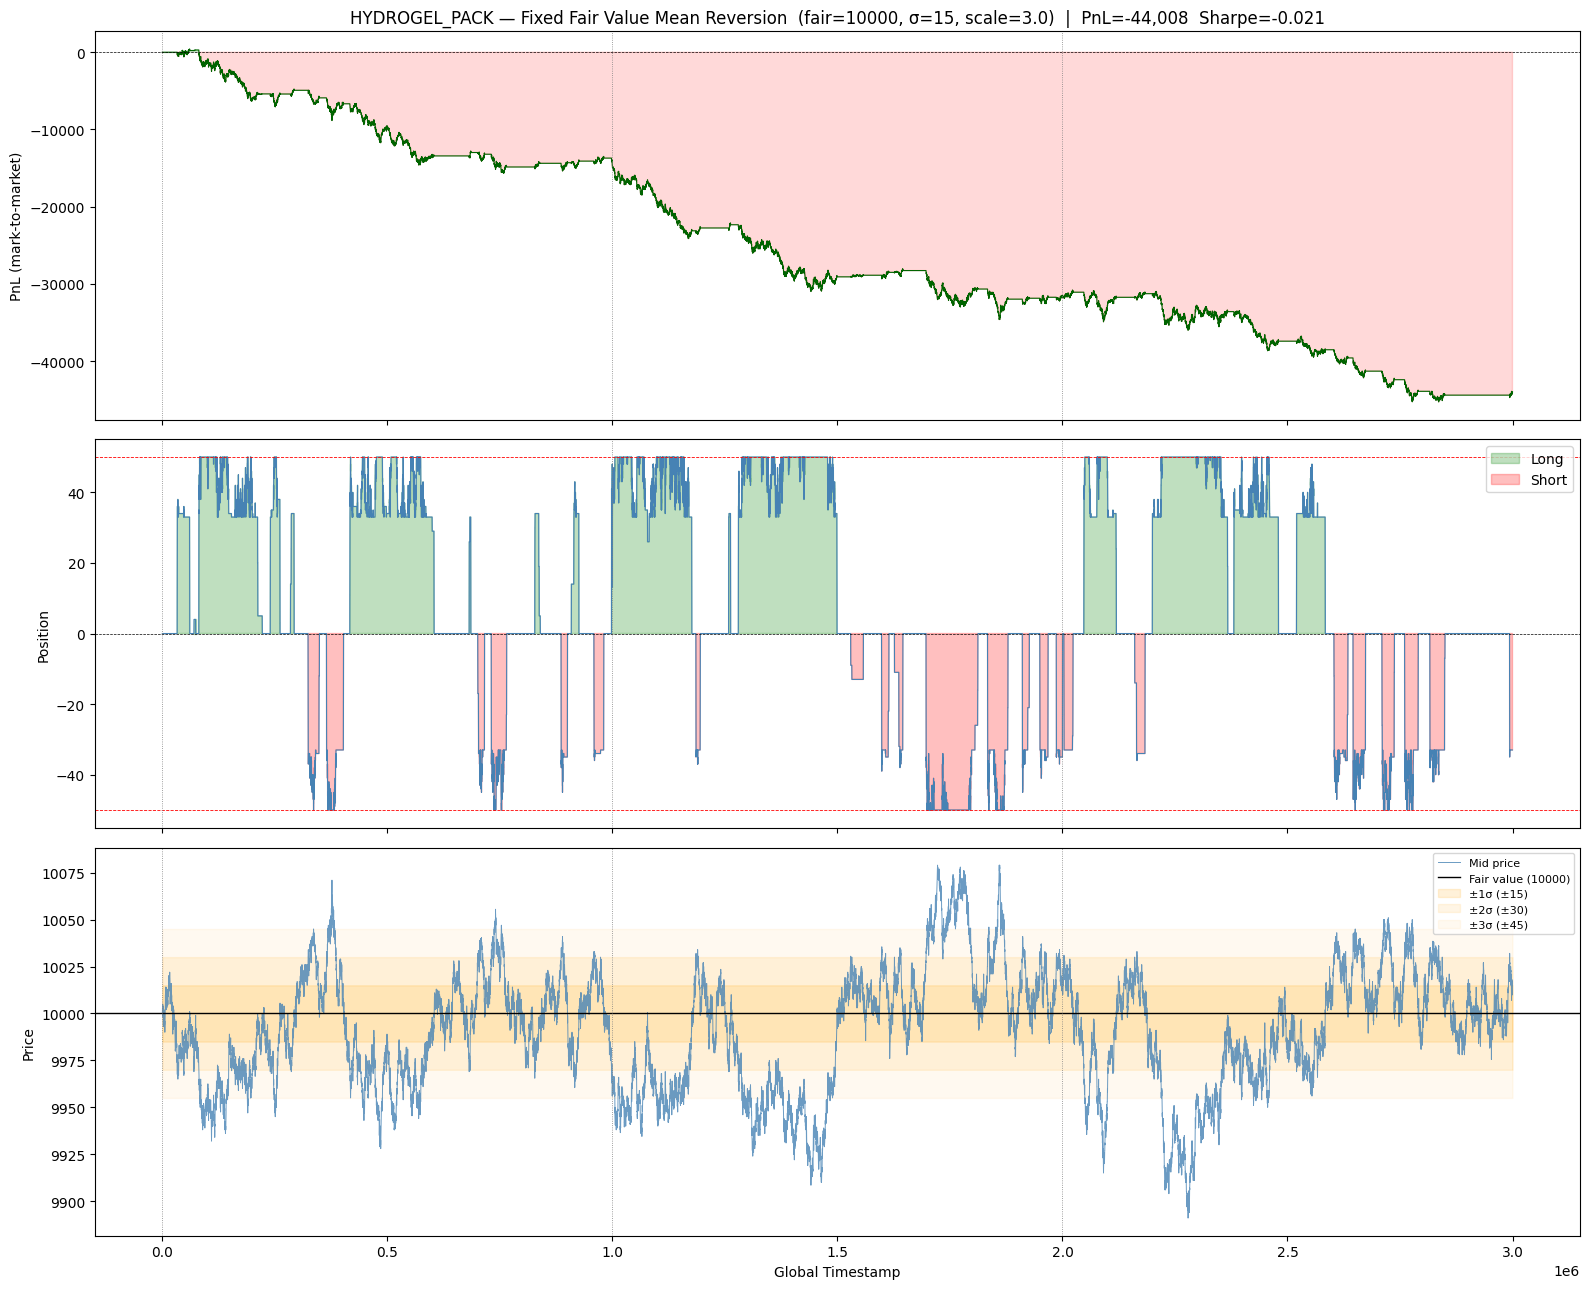

In [150]:
fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True)

day_starts = hg[hg['timestamp'] == 0]['global_timestamp']

# --- PnL ---
axes[0].plot(hg['global_timestamp'], hg['pnl'], linewidth=0.8, color='darkgreen')
axes[0].fill_between(hg['global_timestamp'], hg['pnl'], 0,
                     where=hg['pnl'] >= 0, color='green', alpha=0.15)
axes[0].fill_between(hg['global_timestamp'], hg['pnl'], 0,
                     where=hg['pnl'] <  0, color='red',   alpha=0.15)
axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')
for d in day_starts: axes[0].axvline(d, color='gray', linewidth=0.6, linestyle=':')
axes[0].set_ylabel('PnL (mark-to-market)')
axes[0].set_title(
    f'HYDROGEL_PACK — Fixed Fair Value Mean Reversion  '
    f'(fair={FAIR_VALUE}, σ={STD_DEV}, scale={Z_SCALE})  |  '
    f'PnL={hg["pnl"].iloc[-1]:,.0f}  Sharpe={sharpe:.3f}'
)

# --- Position ---
axes[1].plot(hg['global_timestamp'], hg['position'], linewidth=0.8, color='steelblue')
axes[1].fill_between(hg['global_timestamp'], hg['position'], 0,
                     where=hg['position'] > 0, color='green', alpha=0.25, label='Long')
axes[1].fill_between(hg['global_timestamp'], hg['position'], 0,
                     where=hg['position'] < 0, color='red',   alpha=0.25, label='Short')
axes[1].axhline( POSITION_LIMIT, color='red', linewidth=0.6, linestyle='--')
axes[1].axhline(-POSITION_LIMIT, color='red', linewidth=0.6, linestyle='--')
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
for d in day_starts: axes[1].axvline(d, color='gray', linewidth=0.6, linestyle=':')
axes[1].set_ylabel('Position')
axes[1].legend(loc='upper right')

# --- Mid price vs fair value, with z-score bands ---
axes[2].plot(hg['global_timestamp'], hg['mid_price'], linewidth=0.7, color='steelblue',
             alpha=0.8, label='Mid price')
axes[2].axhline(FAIR_VALUE, color='black', linewidth=1.0, linestyle='-', label=f'Fair value ({FAIR_VALUE})')
for sigma, alpha, label in [(1, 0.15, f'±1σ (±{STD_DEV})'),
                             (2, 0.10, f'±2σ (±{2*STD_DEV})'),
                             (3, 0.06, f'±3σ (±{3*STD_DEV})')]:
    axes[2].fill_between(hg['global_timestamp'],
                         FAIR_VALUE - sigma * STD_DEV,
                         FAIR_VALUE + sigma * STD_DEV,
                         alpha=alpha, color='orange', label=label)
for d in day_starts: axes[2].axvline(d, color='gray', linewidth=0.6, linestyle=':')
axes[2].set_ylabel('Price')
axes[2].set_xlabel('Global Timestamp')
axes[2].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

## Threshold Mean Reversion — Buy ≤ 9950, Sell ≥ 10050

Enter full long when price drops to 9950 or below; enter full short when price rises to 10050 or above.  
Hold the position in the neutral zone — no exit until the opposite threshold fires.  
Execution is volume-limited to best ask (buys) and best bid (sells) each tick.

In [167]:
BUY_THRESHOLD  = 9940
SELL_THRESHOLD = 10040
POSITION_LIMIT = 100

hg = product_dfs['HYDROGEL_PACK'].copy().reset_index(drop=True)

days     = hg['day'].values
bids     = hg['bid_price_1'].values
asks     = hg['ask_price_1'].values
bid_vols = hg['bid_volume_1'].values
ask_vols = hg['ask_volume_1'].values
mids     = hg['mid_price'].values

position    = 0
cash        = 0.0
pnl_history = []
pos_history = []

for k in range(len(hg)):
    if k > 0 and days[k] != days[k - 1]:
        if position != 0:
            cash += position * mids[k - 1]
        position = 0

    bid, ask = bids[k], asks[k]
    bv,  av  = bid_vols[k], ask_vols[k]
    mid      = mids[k]

    if np.isnan(bid) or np.isnan(ask) or np.isnan(bv) or np.isnan(av):
        pnl_history.append(cash + position * mids[k])
        pos_history.append(position)
        continue

    if mid <= BUY_THRESHOLD:
        target = POSITION_LIMIT          # price at or below 9950 → full long
    elif mid >= SELL_THRESHOLD:
        target = -POSITION_LIMIT         # price at or above 10050 → full short
    else:
        target = position             # neutral zone → hold, wait for other threshold

    delta = target - position
    if delta > 0:
        fillable  = min(delta, int(av))  # buy at best ask, limited by available volume
        cash     -= fillable * ask
        position += fillable
    elif delta < 0:
        fillable  = min(-delta, int(bv)) # sell at best bid, limited by available volume
        cash     += fillable * bid
        position -= fillable

    pnl_history.append(cash + position * mids[k])
    pos_history.append(position)

if position != 0:
    cash += position * mids[-1]

hg['pnl']      = pnl_history
hg['position'] = pos_history

pnl_diff = hg['pnl'].diff().dropna()
sharpe   = pnl_diff.mean() / pnl_diff.std()

print(f"Final PnL:         {hg['pnl'].iloc[-1]:>12,.1f}")
print(f"Sharpe (per-tick): {sharpe:>12.4f}")
print(f"Max drawdown:      {(hg['pnl'] - hg['pnl'].cummax()).min():>12,.1f}")
print(f"Trades:            {(hg['position'].diff() != 0).sum():>12,}")
print(f"Ticks at buy zone: {(mids <= BUY_THRESHOLD).sum():>12,}")
print(f"Ticks at sell zone:{(mids >= SELL_THRESHOLD).sum():>12,}")

Final PnL:             56,778.0
Sharpe (per-tick):       0.0091
Max drawdown:         -14,200.0
Trades:                     110
Ticks at buy zone:        1,690
Ticks at sell zone:       1,635


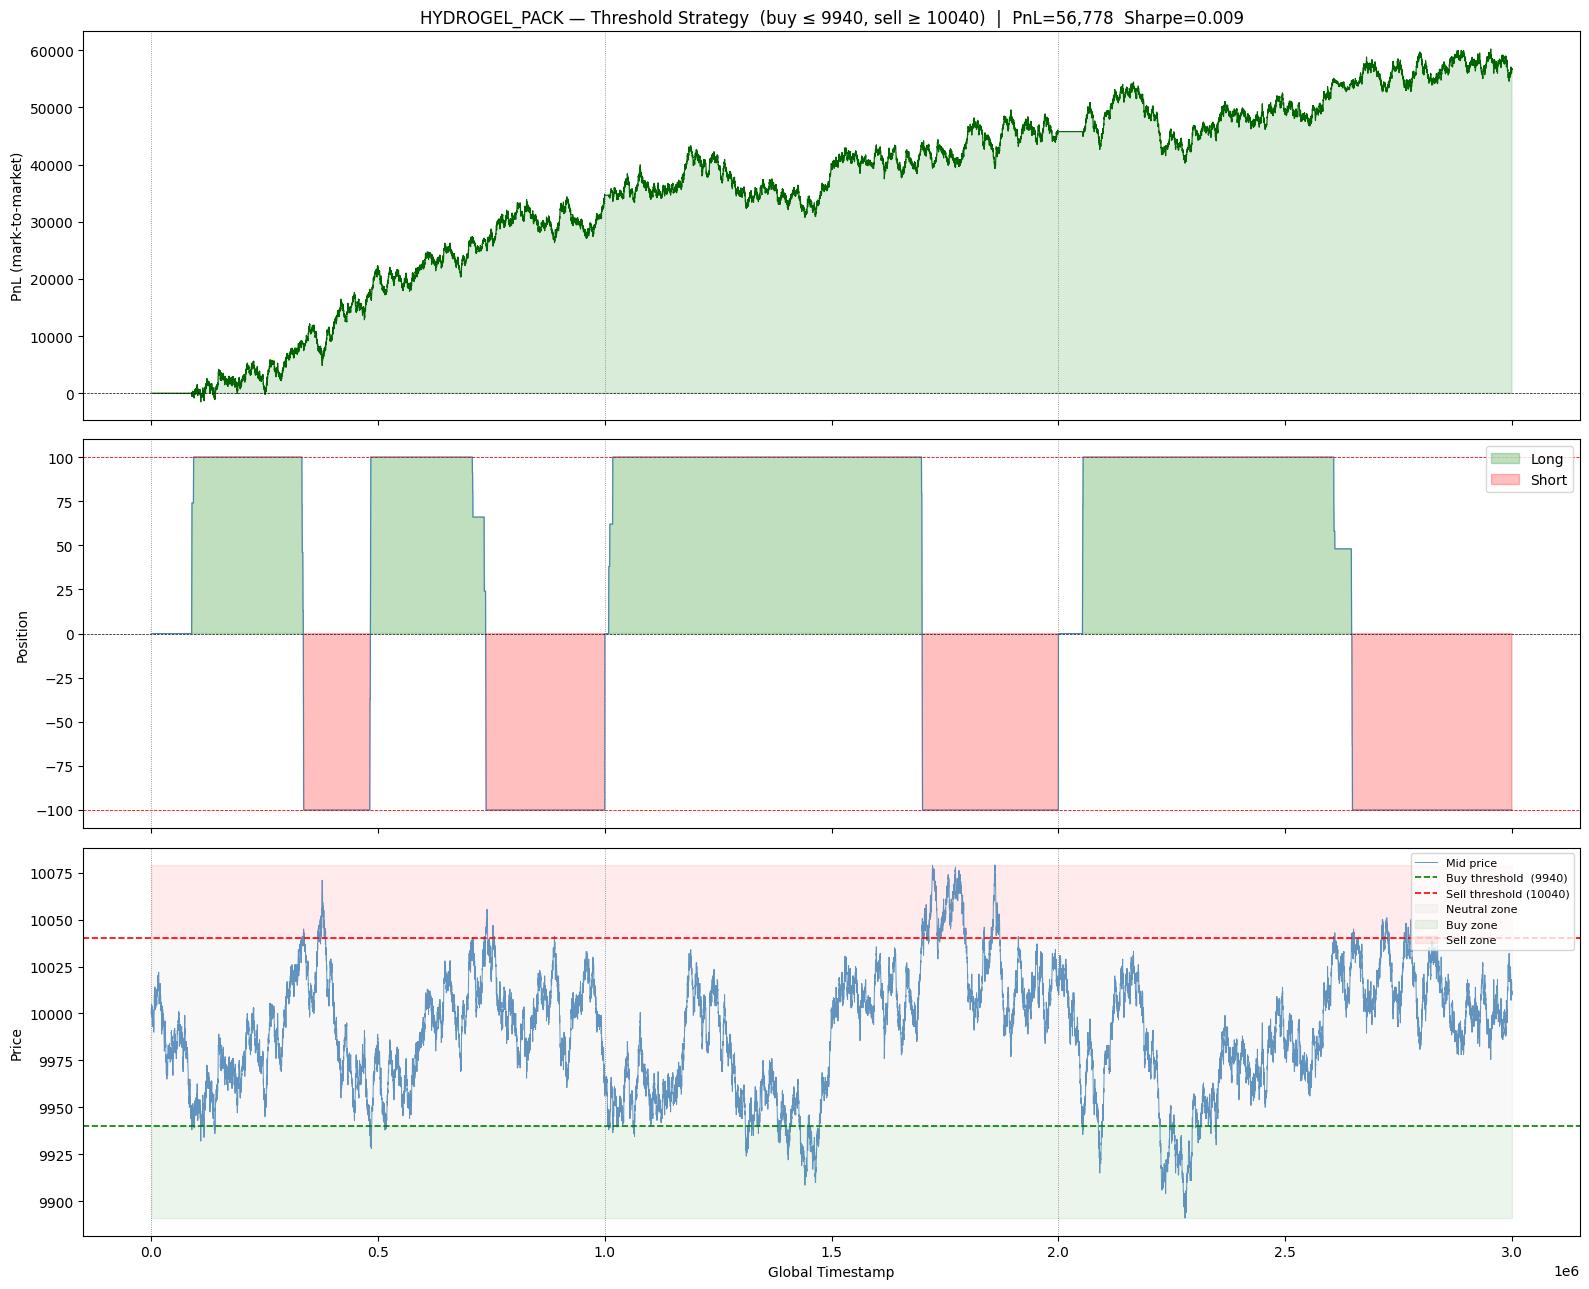

In [168]:
fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True)

day_starts = hg[hg['timestamp'] == 0]['global_timestamp']

# --- PnL ---
axes[0].plot(hg['global_timestamp'], hg['pnl'], linewidth=0.8, color='darkgreen')
axes[0].fill_between(hg['global_timestamp'], hg['pnl'], 0,
                     where=hg['pnl'] >= 0, color='green', alpha=0.15)
axes[0].fill_between(hg['global_timestamp'], hg['pnl'], 0,
                     where=hg['pnl'] <  0, color='red',   alpha=0.15)
axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')
for d in day_starts: axes[0].axvline(d, color='gray', linewidth=0.6, linestyle=':')
axes[0].set_ylabel('PnL (mark-to-market)')
axes[0].set_title(
    f'HYDROGEL_PACK — Threshold Strategy  '
    f'(buy ≤ {BUY_THRESHOLD}, sell ≥ {SELL_THRESHOLD})  |  '
    f'PnL={hg["pnl"].iloc[-1]:,.0f}  Sharpe={sharpe:.3f}'
)

# --- Position ---
axes[1].plot(hg['global_timestamp'], hg['position'], linewidth=0.8, color='steelblue')
axes[1].fill_between(hg['global_timestamp'], hg['position'], 0,
                     where=hg['position'] > 0, color='green', alpha=0.25, label='Long')
axes[1].fill_between(hg['global_timestamp'], hg['position'], 0,
                     where=hg['position'] < 0, color='red',   alpha=0.25, label='Short')
axes[1].axhline( POSITION_LIMIT, color='red', linewidth=0.6, linestyle='--')
axes[1].axhline(-POSITION_LIMIT, color='red', linewidth=0.6, linestyle='--')
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
for d in day_starts: axes[1].axvline(d, color='gray', linewidth=0.6, linestyle=':')
axes[1].set_ylabel('Position')
axes[1].legend(loc='upper right')

# --- Price with threshold bands ---
axes[2].plot(hg['global_timestamp'], hg['mid_price'], linewidth=0.7, color='steelblue',
             alpha=0.85, label='Mid price')
axes[2].axhline(BUY_THRESHOLD,  color='green', linewidth=1.2, linestyle='--',
                label=f'Buy threshold  ({BUY_THRESHOLD})')
axes[2].axhline(SELL_THRESHOLD, color='red',   linewidth=1.2, linestyle='--',
                label=f'Sell threshold ({SELL_THRESHOLD})')
axes[2].fill_between(hg['global_timestamp'], BUY_THRESHOLD, SELL_THRESHOLD,
                     alpha=0.05, color='gray', label='Neutral zone')
axes[2].fill_between(hg['global_timestamp'], hg['mid_price'].min(), BUY_THRESHOLD,
                     alpha=0.08, color='green', label='Buy zone')
axes[2].fill_between(hg['global_timestamp'], SELL_THRESHOLD, hg['mid_price'].max(),
                     alpha=0.08, color='red',   label='Sell zone')
for d in day_starts: axes[2].axvline(d, color='gray', linewidth=0.6, linestyle=':')
axes[2].set_ylabel('Price')
axes[2].set_xlabel('Global Timestamp')
axes[2].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()